# X-shooter orbits in the time-dependent MW + LMC + SMC potential

This notebook loads the already-integrated central trajectories. Each plotting cell creates one figure directly with `plt.subplots`, without project-specific plotting functions, so the styling and selections can be edited in place.

The final two panels show the instantaneous three-dimensional star–LMC and star–SMC separations.

In [134]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import Galactocentric, Galactic, SkyCoord

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
})

# Find the repository whether the notebook starts in Delve/ or Delve/notebooks/.
repo_root = Path.cwd()
if not (repo_root / "Data").is_dir():
    repo_root = repo_root.parent

trajectory_files = {
    "GaiaEDR3": repo_root / "Plots/orbits_lmc/xshooter_central_orbits_mollweide.npz",
    "K13Z18": repo_root / "Plots/orbits_lmc/xshooter_central_orbits_K13Z18_mollweide.npz",
}
sample_trajectory_file = repo_root / "Data/orbits_lmc/xshooter_orbit_samples_GaiaEDR3.npz"

# The five main figures below deliberately use GaiaEDR3.
trajectory_file = trajectory_files["K13Z18"]

# Maximum lookback time shown by the Mollweide and Galactocentric Y–Z orbit cells.
# Use None to keep the full integrated trajectory.
max_plot_lookback_gyr = 0.4 # None 
sampled_orbit_alpha = 0.1
central_orbit_alpha = 0.95
trajectory_files

{'GaiaEDR3': PosixPath('/Users/mncavieres/Documents/2026-1/Delve/Plots/orbits_lmc/xshooter_central_orbits_mollweide.npz'),
 'K13Z18': PosixPath('/Users/mncavieres/Documents/2026-1/Delve/Plots/orbits_lmc/xshooter_central_orbits_K13Z18_mollweide.npz')}

In [135]:
# Load the stellar and satellite trajectories.
archive = np.load(trajectory_file)
assert str(archive["orbit_family"]) == "K13Z18"

labels = archive["labels"].astype(str)
times = archive["times"]                         # (Nstar, Ntime), AGAMA time units
star_phase_space = archive["phase_space"]       # x,y,z,vx,vy,vz
star_xyz = star_phase_space[:, :, :3]            # kpc, MW-centered Galactocentric frame
lmc_track = archive["lmc_track"]                # t,x,y,z,vx,vy,vz, MW-centered
smc_track = archive["smc_track"]

mass_lmc = float(archive["mass_lmc"])
scale_lmc = float(archive["scale_lmc"])
mass_smc = float(archive["mass_smc"])
scale_smc = float(archive["scale_smc"])

# All stellar trajectories use the same sampling. One AGAMA time unit is 0.977792 Gyr.
assert np.allclose(times, times[0][None, :])
common_time = times[0]
agama_time_in_gyr = 0.97779222168
lookback_time = -common_time * agama_time_in_gyr

if max_plot_lookback_gyr is None:
    orbit_plot_mask = np.ones_like(lookback_time, dtype=bool)
else:
    if max_plot_lookback_gyr <= 0:
        raise ValueError("max_plot_lookback_gyr must be positive or None")
    orbit_plot_mask = lookback_time <= max_plot_lookback_gyr

if not np.any(orbit_plot_mask):
    raise ValueError("max_plot_lookback_gyr selects no trajectory samples")

plot_lookback_time = lookback_time[orbit_plot_mask]

# Interpolate the moving Cloud centers onto the stellar time samples.
lmc_xyz = np.column_stack([
    np.interp(common_time, lmc_track[:, 0], lmc_track[:, column])
    for column in range(1, 4)
])
smc_xyz = np.column_stack([
    np.interp(common_time, smc_track[:, 0], smc_track[:, column])
    for column in range(1, 4)
])

# Radii used in the three time-series figures.
star_galactocentric_radius = np.linalg.norm(star_xyz, axis=2)
star_lmc_radius = np.linalg.norm(star_xyz - lmc_xyz[None, :, :], axis=2)
star_smc_radius = np.linalg.norm(star_xyz - smc_xyz[None, :, :], axis=2)

# Shorter labels and a stable color for each candidate across every panel.
short_labels = [label.replace("GaiaDR3_", "") for label in labels]
colors = plt.get_cmap("tab10").colors

# Load the independently integrated K13Z18 realization for the comparison cells.
k13_archive = np.load(trajectory_files["K13Z18"])
assert str(k13_archive["orbit_family"]) == "K13Z18"
k13_times = k13_archive["times"]
k13_star_xyz = k13_archive["phase_space"][:, :, :3]
k13_lmc_track = k13_archive["lmc_track"]
k13_smc_track = k13_archive["smc_track"]
assert np.allclose(k13_times, times)
k13_lmc_xyz = np.column_stack([
    np.interp(common_time, k13_lmc_track[:, 0], k13_lmc_track[:, column])
    for column in range(1, 4)
])
k13_smc_xyz = np.column_stack([
    np.interp(common_time, k13_smc_track[:, 0], k13_smc_track[:, column])
    for column in range(1, 4)
])

# Load 10 GaiaEDR3 tracks per star: one central orbit and nine uncertainty draws.
sample_archive = np.load(sample_trajectory_file)
assert str(sample_archive["orbit_family"]) == "GaiaEDR3"
sample_labels = sample_archive["labels"].astype(str)
sample_time = sample_archive["times"]
sample_star_xyz = sample_archive["phase_space"][:, :, :, :3]
sample_is_central = sample_archive["is_central"].astype(bool)
assert np.array_equal(sample_labels, labels)
assert sample_star_xyz.shape[1] == 10
assert sample_is_central.sum() == 1 and sample_is_central[0]

sample_lookback_time = -sample_time * agama_time_in_gyr
if max_plot_lookback_gyr is None:
    sample_orbit_plot_mask = np.ones_like(sample_lookback_time, dtype=bool)
else:
    sample_orbit_plot_mask = sample_lookback_time <= max_plot_lookback_gyr

sample_lmc_track = sample_archive["lmc_track"]
sample_smc_track = sample_archive["smc_track"]
sample_lmc_xyz = np.column_stack([
    np.interp(sample_time, sample_lmc_track[:, 0], sample_lmc_track[:, column])
    for column in range(1, 4)
])
sample_smc_xyz = np.column_stack([
    np.interp(sample_time, sample_smc_track[:, 0], sample_smc_track[:, column])
    for column in range(1, 4)
])

print(f"Loaded {len(labels)} stellar trajectories with {len(common_time)} samples each")
print(f"Loaded {sample_star_xyz.shape[1]} GaiaEDR3 orbit tracks per star for Mollweide plotting")
print(f"Time range: {lookback_time.min():.3f}–{lookback_time.max():.3f} Gyr lookback")
print(f"LMC Plummer model: M={mass_lmc:.2e} Msun, a={scale_lmc:g} kpc")
print(f"SMC Plummer model: M={mass_smc:.2e} Msun, a={scale_smc:g} kpc")

Loaded 7 stellar trajectories with 1001 samples each
Loaded 10 GaiaEDR3 orbit tracks per star for Mollweide plotting
Time range: -0.000–5.867 Gyr lookback
LMC Plummer model: M=1.50e+11 Msun, a=18 kpc
SMC Plummer model: M=1.00e+10 Msun, a=5 kpc


## 1. Mollweide sky projection

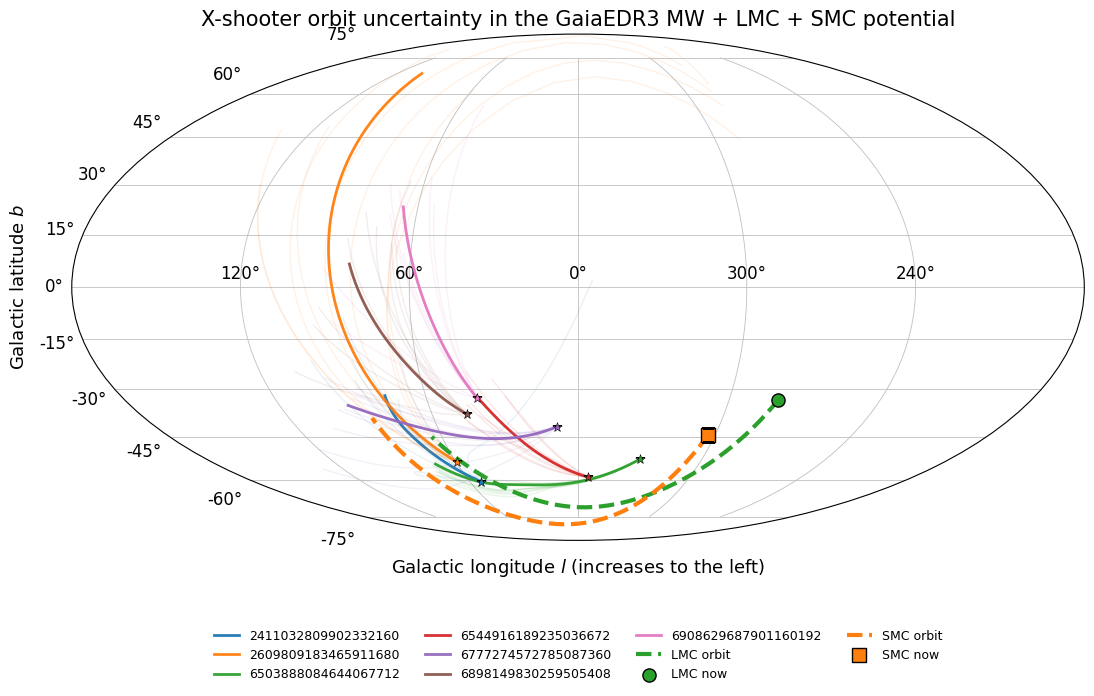

In [136]:
# Mollweide plot with one central orbit and nine uncertainty draws per star.
fig, ax = plt.subplots(
    figsize=(13, 7),
    subplot_kw={"projection": "mollweide"},
    constrained_layout=True,
)

star_sky = SkyCoord(
    x=sample_star_xyz[:, :, sample_orbit_plot_mask, 0].ravel() * u.kpc,
    y=sample_star_xyz[:, :, sample_orbit_plot_mask, 1].ravel() * u.kpc,
    z=sample_star_xyz[:, :, sample_orbit_plot_mask, 2].ravel() * u.kpc,
    frame=Galactocentric(),
).transform_to(Galactic())
sample_plot_shape = sample_star_xyz[:, :, sample_orbit_plot_mask].shape[:3]
star_longitude = star_sky.l.wrap_at(180 * u.deg).to_value(u.rad).reshape(sample_plot_shape)
star_latitude = star_sky.b.to_value(u.rad).reshape(sample_plot_shape)

for index, label in enumerate(short_labels):
    color = colors[index % len(colors)]
    for sample_index in np.flatnonzero(~sample_is_central):
        x_plot = -star_longitude[index, sample_index].copy()
        y_plot = star_latitude[index, sample_index].copy()
        seam = np.flatnonzero(np.abs(np.diff(x_plot)) > np.pi) + 1
        x_plot[seam] = np.nan
        y_plot[seam] = np.nan
        ax.plot(x_plot, y_plot, color=color, lw=1.0, alpha=sampled_orbit_alpha)

    central_index = int(np.flatnonzero(sample_is_central)[0])
    x_plot = -star_longitude[index, central_index].copy()
    y_plot = star_latitude[index, central_index].copy()
    seam = np.flatnonzero(np.abs(np.diff(x_plot)) > np.pi) + 1
    x_plot[seam] = np.nan
    y_plot[seam] = np.nan
    ax.plot(x_plot, y_plot, color=color, lw=2.0, alpha=central_orbit_alpha, label=label)
    ax.scatter(
        -star_longitude[index, central_index, 0], star_latitude[index, central_index, 0],
        marker="*", s=50, color=color,
        edgecolor="black", linewidth=0.4, zorder=5,
    )

lmc_sky = SkyCoord(
    x=sample_lmc_xyz[sample_orbit_plot_mask, 0] * u.kpc, y=sample_lmc_xyz[sample_orbit_plot_mask, 1] * u.kpc, z=sample_lmc_xyz[sample_orbit_plot_mask, 2] * u.kpc,
    frame=Galactocentric(),
).transform_to(Galactic())
lmc_longitude = -lmc_sky.l.wrap_at(180 * u.deg).to_value(u.rad)
lmc_latitude = lmc_sky.b.to_value(u.rad)
lmc_seam = np.flatnonzero(np.abs(np.diff(lmc_longitude)) > np.pi) + 1
lmc_longitude[lmc_seam] = np.nan
lmc_latitude[lmc_seam] = np.nan
ax.plot(lmc_longitude, lmc_latitude, "--", color="tab:green", lw=3, label="LMC orbit")
ax.scatter(lmc_longitude[0], lmc_latitude[0], s=90, marker="o", color="tab:green",
           edgecolor="black", zorder=6, label="LMC now")

smc_sky = SkyCoord(
    x=sample_smc_xyz[sample_orbit_plot_mask, 0] * u.kpc, y=sample_smc_xyz[sample_orbit_plot_mask, 1] * u.kpc, z=sample_smc_xyz[sample_orbit_plot_mask, 2] * u.kpc,
    frame=Galactocentric(),
).transform_to(Galactic())
smc_longitude = -smc_sky.l.wrap_at(180 * u.deg).to_value(u.rad)
smc_latitude = smc_sky.b.to_value(u.rad)
smc_seam = np.flatnonzero(np.abs(np.diff(smc_longitude)) > np.pi) + 1
smc_longitude[smc_seam] = np.nan
smc_latitude[smc_seam] = np.nan
ax.plot(smc_longitude, smc_latitude, "--", color="tab:orange", lw=3, label="SMC orbit")
ax.scatter(smc_longitude[0], smc_latitude[0], s=90, marker="s", color="tab:orange",
           edgecolor="black", zorder=6, label="SMC now")

longitude_ticks = np.arange(-120, 180, 60)
ax.set_xticks(
    np.deg2rad(longitude_ticks),
    labels=[f"{int((-value) % 360)}°" for value in longitude_ticks],
)
ax.set_title("X-shooter orbit uncertainty in the GaiaEDR3 MW + LMC + SMC potential")
ax.set_xlabel("Galactic longitude $l$ (increases to the left)", labelpad=12)
ax.set_ylabel("Galactic latitude $b$", labelpad=8)
ax.grid(color="0.75", linewidth=0.6)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.30), ncol=4, frameon=False)

# fig.savefig(repo_root / "Plots/orbits_lmc/notebook_mollweide.png", dpi=220, bbox_inches="tight")
plt.show()


## 2. Galactocentric $Y$–$Z$ projection

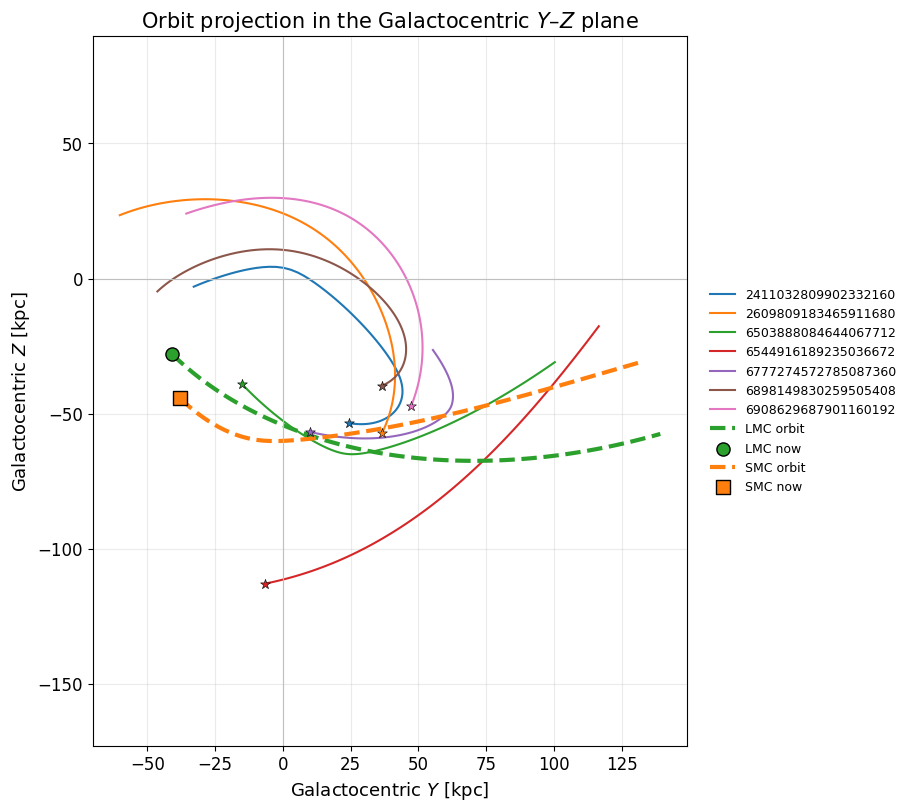

In [117]:
# Galactocentric Y versus Z.
fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)

for index, label in enumerate(short_labels):
    ax.plot(
        star_xyz[index, orbit_plot_mask, 1], star_xyz[index, orbit_plot_mask, 2],
        color=colors[index % len(colors)], label=label,
    )
    ax.scatter(
        star_xyz[index, orbit_plot_mask, 1][0], star_xyz[index, orbit_plot_mask, 2][0],
        marker="*", s=55, color=colors[index % len(colors)],
        edgecolor="black", linewidth=0.4, zorder=5,
    )

ax.plot(lmc_xyz[orbit_plot_mask, 1], lmc_xyz[orbit_plot_mask, 2], "--", color="tab:green", lw=3, label="LMC orbit")
ax.scatter(lmc_xyz[orbit_plot_mask, 1][0], lmc_xyz[orbit_plot_mask, 2][0], s=90, color="tab:green",
           edgecolor="black", zorder=6, label="LMC now")
ax.plot(smc_xyz[orbit_plot_mask, 1], smc_xyz[orbit_plot_mask, 2], "--", color="tab:orange", lw=3, label="SMC orbit")
ax.scatter(smc_xyz[orbit_plot_mask, 1][0], smc_xyz[orbit_plot_mask, 2][0], s=90, marker="s", color="tab:orange",
           edgecolor="black", zorder=6, label="SMC now")

ax.axhline(0, color="0.75", lw=0.8)
ax.axvline(0, color="0.75", lw=0.8)
ax.set_xlabel("Galactocentric $Y$ [kpc]")
ax.set_ylabel("Galactocentric $Z$ [kpc]")
ax.set_title("Orbit projection in the Galactocentric $Y$–$Z$ plane")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.25)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# fig.savefig(repo_root / "Plots/orbits_lmc/notebook_yz.png", dpi=220, bbox_inches="tight")
plt.show()

## 3. Lookback time versus Galactocentric radius

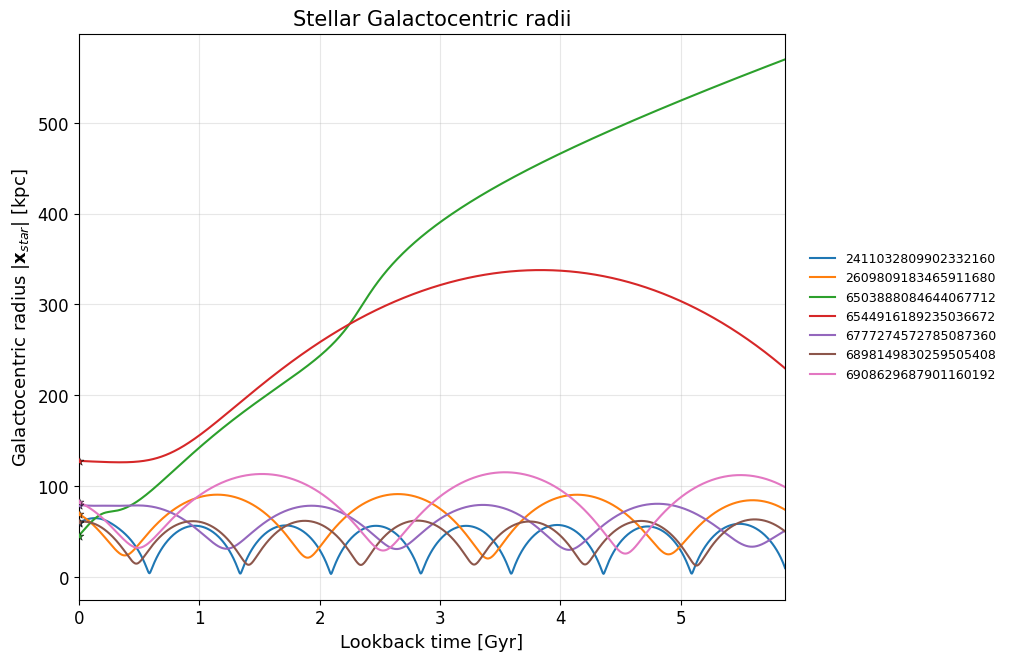

In [118]:
# Three-dimensional distance between each star and the Galactic center.
fig, ax = plt.subplots(figsize=(10, 6.5), constrained_layout=True)

for index, label in enumerate(short_labels):
    ax.plot(
        lookback_time, star_galactocentric_radius[index],
        color=colors[index % len(colors)], label=label,
    )
    ax.scatter(
        lookback_time[0], star_galactocentric_radius[index, 0],
        marker="*", s=45, color=colors[index % len(colors)],
        edgecolor="black", linewidth=0.35, zorder=5,
    )

ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel("Galactocentric radius $|\\mathbf{x}_{star}|$ [kpc]")
ax.set_title("Stellar Galactocentric radii")
ax.set_xlim(lookback_time.min(), lookback_time.max())
ax.grid(alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# fig.savefig(repo_root / "Plots/orbits_lmc/notebook_galactocentric_radius.png", dpi=220, bbox_inches="tight")
plt.show()

## 4. Lookback time versus distance from the LMC

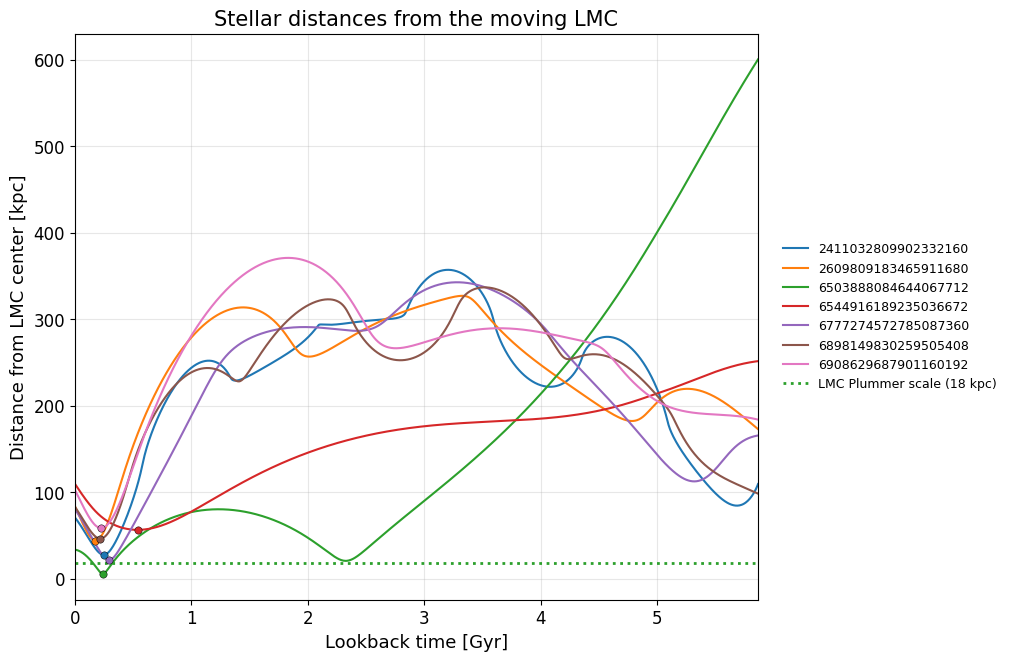

In [119]:
# Instantaneous three-dimensional star–LMC separation.
fig, ax = plt.subplots(figsize=(10, 6.5), constrained_layout=True)

for index, label in enumerate(short_labels):
    ax.plot(
        lookback_time, star_lmc_radius[index],
        color=colors[index % len(colors)], label=label,
    )
    minimum_index = np.argmin(star_lmc_radius[index])
    ax.scatter(
        lookback_time[minimum_index], star_lmc_radius[index, minimum_index],
        s=28, color=colors[index % len(colors)], edgecolor="black",
        linewidth=0.35, zorder=5,
    )

ax.axhline(scale_lmc, color="tab:green", ls=":", lw=2,
           label=f"LMC Plummer scale ({scale_lmc:g} kpc)")
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel("Distance from LMC center [kpc]")
ax.set_title("Stellar distances from the moving LMC")
ax.set_xlim(lookback_time.min(), lookback_time.max())
ax.grid(alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# fig.savefig(repo_root / "Plots/orbits_lmc/notebook_lmc_radius.png", dpi=220, bbox_inches="tight")
plt.show()

## 5. Lookback time versus distance from the SMC

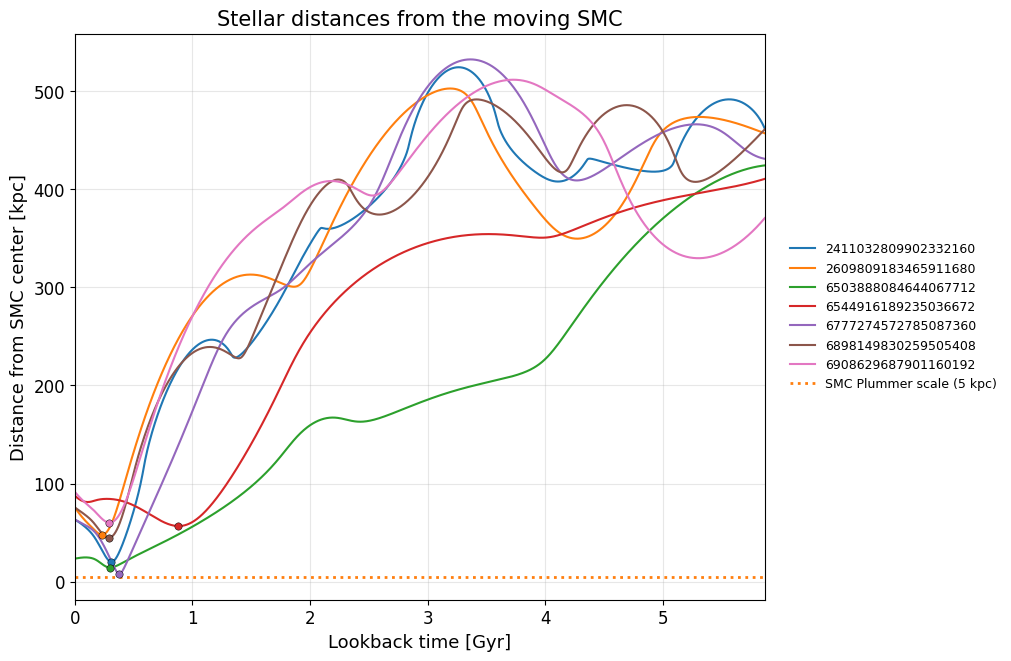

In [120]:
# Instantaneous three-dimensional star–SMC separation.
fig, ax = plt.subplots(figsize=(10, 6.5), constrained_layout=True)

for index, label in enumerate(short_labels):
    ax.plot(
        lookback_time, star_smc_radius[index],
        color=colors[index % len(colors)], label=label,
    )
    minimum_index = np.argmin(star_smc_radius[index])
    ax.scatter(
        lookback_time[minimum_index], star_smc_radius[index, minimum_index],
        s=28, color=colors[index % len(colors)], edgecolor="black",
        linewidth=0.35, zorder=5,
    )

ax.axhline(scale_smc, color="tab:orange", ls=":", lw=2,
           label=f"SMC Plummer scale ({scale_smc:g} kpc)")
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel("Distance from SMC center [kpc]")
ax.set_title("Stellar distances from the moving SMC")
ax.set_xlim(lookback_time.min(), lookback_time.max())
ax.grid(alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# fig.savefig(repo_root / "Plots/orbits_lmc/notebook_smc_radius.png", dpi=220, bbox_inches="tight")
plt.show()

## GaiaEDR3 versus K13Z18 comparison

The stars are independently re-integrated in each trajectory family. The supplied K13Z18 files have one important naming inconsistency: its LMC filename contains `MW1_5e12`, while its MW and SMC filenames contain `MW1e12`. The plots below use the only complete K13Z18-labelled set available in `Data/LMC_orbits_new`.

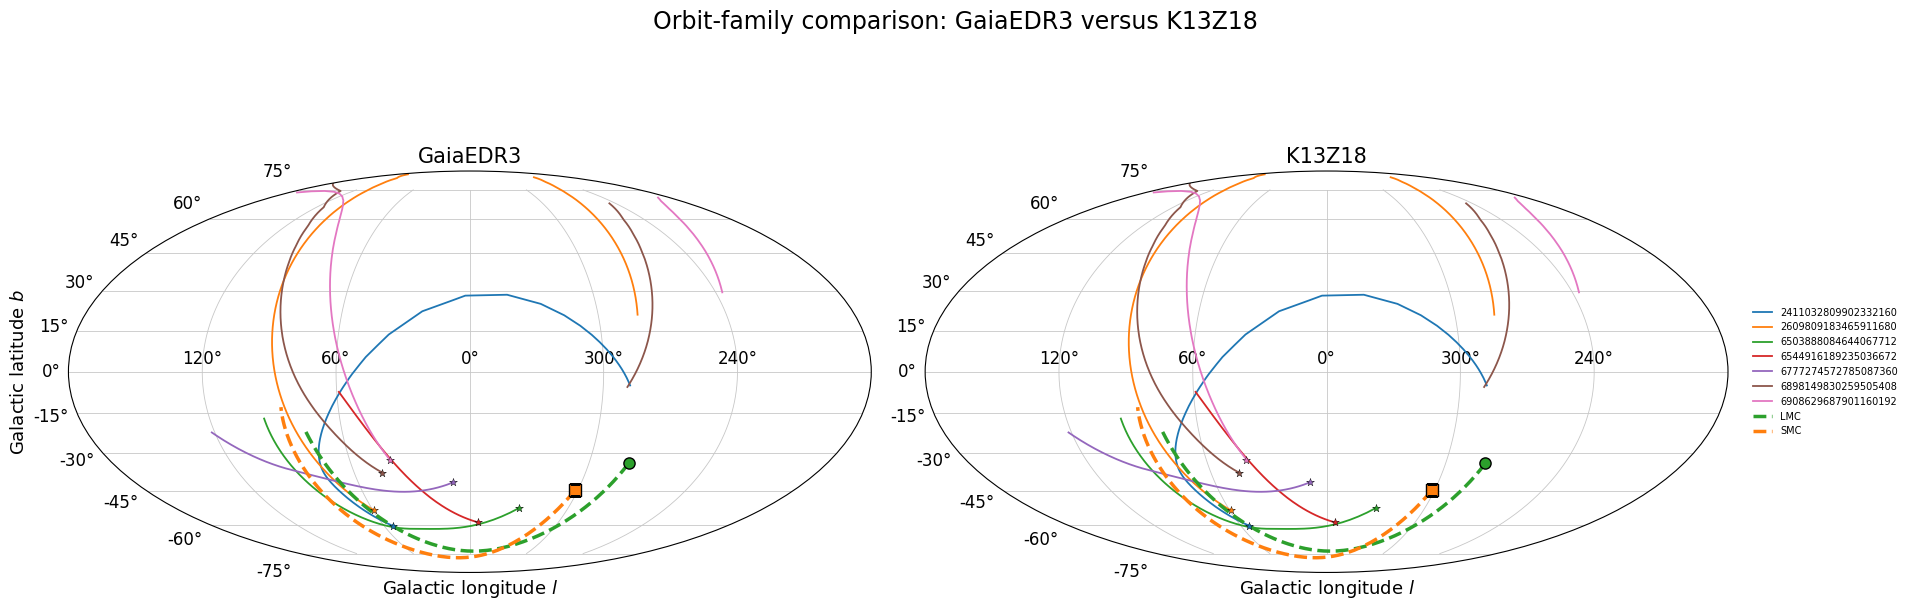

In [121]:
# Side-by-side Mollweide comparison of independently integrated orbit families.
fig, axes = plt.subplots(
    1, 2, figsize=(19, 7),
    subplot_kw={"projection": "mollweide"},
    constrained_layout=True,
)

family_data = [
    ("GaiaEDR3", star_xyz, lmc_xyz, smc_xyz),
    ("K13Z18", k13_star_xyz, k13_lmc_xyz, k13_smc_xyz),
]

for ax, (family_name, family_star_xyz, family_lmc_xyz, family_smc_xyz) in zip(axes, family_data):
    family_star_xyz = family_star_xyz[:, orbit_plot_mask]
    family_lmc_xyz = family_lmc_xyz[orbit_plot_mask]
    family_smc_xyz = family_smc_xyz[orbit_plot_mask]
    family_star_sky = SkyCoord(
        x=family_star_xyz[:, :, 0].ravel() * u.kpc,
        y=family_star_xyz[:, :, 1].ravel() * u.kpc,
        z=family_star_xyz[:, :, 2].ravel() * u.kpc,
        frame=Galactocentric(),
    ).transform_to(Galactic())
    family_star_longitude = family_star_sky.l.wrap_at(180 * u.deg).to_value(u.rad).reshape(family_star_xyz.shape[:2])
    family_star_latitude = family_star_sky.b.to_value(u.rad).reshape(family_star_xyz.shape[:2])

    for index, label in enumerate(short_labels):
        x_plot = -family_star_longitude[index].copy()
        y_plot = family_star_latitude[index].copy()
        seam = np.flatnonzero(np.abs(np.diff(x_plot)) > np.pi) + 1
        x_plot[seam] = np.nan
        y_plot[seam] = np.nan
        ax.plot(x_plot, y_plot, color=colors[index % len(colors)], lw=1.3, label=label)
        ax.scatter(-family_star_longitude[index, 0], family_star_latitude[index, 0],
                   marker="*", s=35, color=colors[index % len(colors)],
                   edgecolor="black", linewidth=0.3, zorder=5)

    family_lmc_sky = SkyCoord(
        x=family_lmc_xyz[:, 0] * u.kpc, y=family_lmc_xyz[:, 1] * u.kpc,
        z=family_lmc_xyz[:, 2] * u.kpc, frame=Galactocentric(),
    ).transform_to(Galactic())
    family_lmc_longitude = -family_lmc_sky.l.wrap_at(180 * u.deg).to_value(u.rad)
    family_lmc_latitude = family_lmc_sky.b.to_value(u.rad)
    seam = np.flatnonzero(np.abs(np.diff(family_lmc_longitude)) > np.pi) + 1
    family_lmc_longitude[seam] = np.nan
    family_lmc_latitude[seam] = np.nan
    ax.plot(family_lmc_longitude, family_lmc_latitude, "--", color="tab:green", lw=2.5, label="LMC")
    ax.scatter(family_lmc_longitude[0], family_lmc_latitude[0], s=65, color="tab:green",
               edgecolor="black", zorder=6)

    family_smc_sky = SkyCoord(
        x=family_smc_xyz[:, 0] * u.kpc, y=family_smc_xyz[:, 1] * u.kpc,
        z=family_smc_xyz[:, 2] * u.kpc, frame=Galactocentric(),
    ).transform_to(Galactic())
    family_smc_longitude = -family_smc_sky.l.wrap_at(180 * u.deg).to_value(u.rad)
    family_smc_latitude = family_smc_sky.b.to_value(u.rad)
    seam = np.flatnonzero(np.abs(np.diff(family_smc_longitude)) > np.pi) + 1
    family_smc_longitude[seam] = np.nan
    family_smc_latitude[seam] = np.nan
    ax.plot(family_smc_longitude, family_smc_latitude, "--", color="tab:orange", lw=2.5, label="SMC")
    ax.scatter(family_smc_longitude[0], family_smc_latitude[0], s=65, marker="s",
               color="tab:orange", edgecolor="black", zorder=6)

    longitude_ticks = np.arange(-120, 180, 60)
    ax.set_xticks(np.deg2rad(longitude_ticks),
                  labels=[f"{int((-value) % 360)}°" for value in longitude_ticks])
    ax.set_title(family_name)
    ax.set_xlabel("Galactic longitude $l$")
    ax.grid(color="0.78", linewidth=0.6)

axes[0].set_ylabel("Galactic latitude $b$")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=7)
fig.suptitle("Orbit-family comparison: GaiaEDR3 versus K13Z18", fontsize=17)

# fig.savefig(repo_root / "Plots/orbits_lmc/notebook_family_mollweide_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

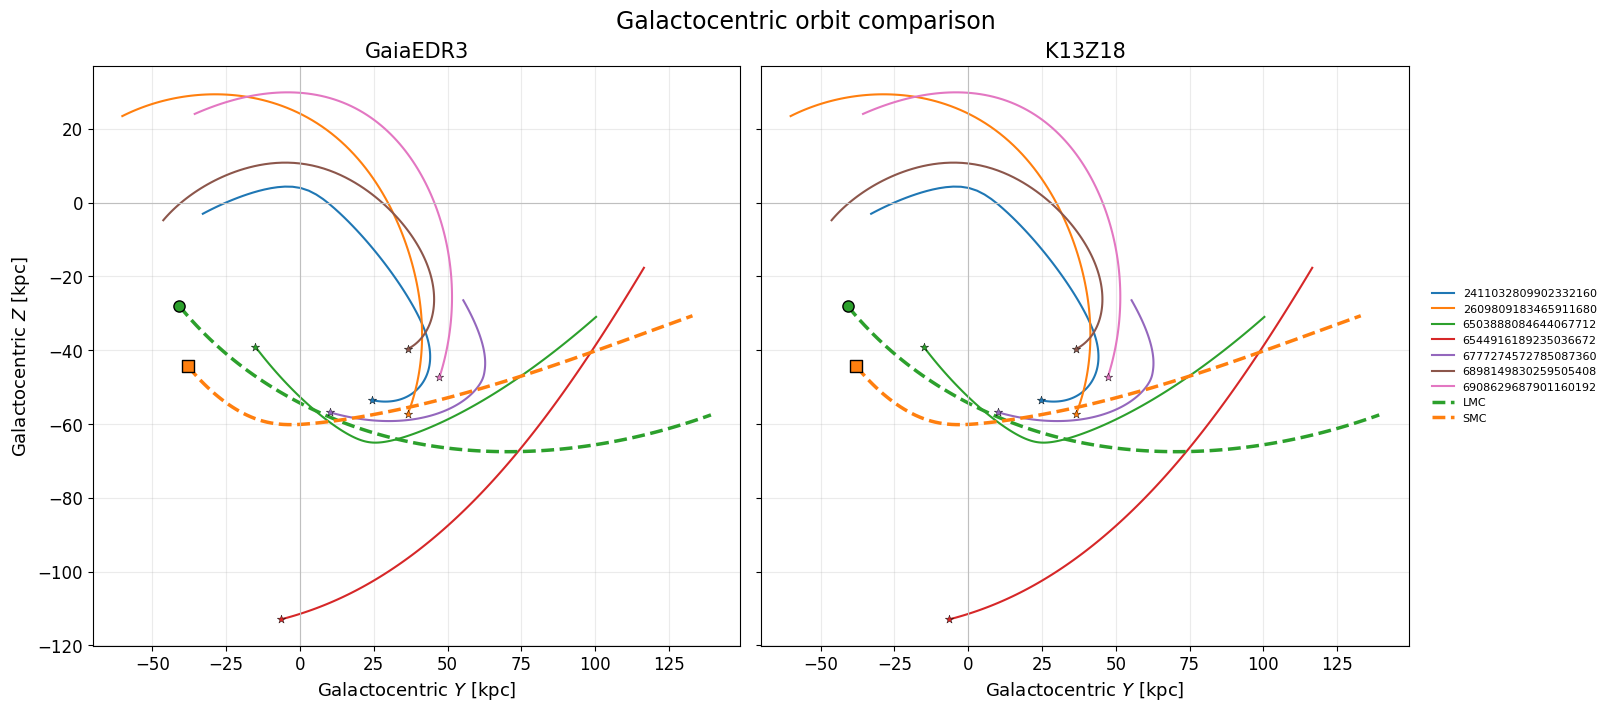

In [122]:
# Side-by-side Galactocentric Y–Z comparison using identical limits.
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True, constrained_layout=True)

family_data = [
    ("GaiaEDR3", star_xyz, lmc_xyz, smc_xyz),
    ("K13Z18", k13_star_xyz, k13_lmc_xyz, k13_smc_xyz),
]

for ax, (family_name, family_star_xyz, family_lmc_xyz, family_smc_xyz) in zip(axes, family_data):
    family_star_xyz = family_star_xyz[:, orbit_plot_mask]
    family_lmc_xyz = family_lmc_xyz[orbit_plot_mask]
    family_smc_xyz = family_smc_xyz[orbit_plot_mask]
    for index, label in enumerate(short_labels):
        ax.plot(family_star_xyz[index, :, 1], family_star_xyz[index, :, 2],
                color=colors[index % len(colors)], label=label)
        ax.scatter(family_star_xyz[index, 0, 1], family_star_xyz[index, 0, 2],
                   marker="*", s=40, color=colors[index % len(colors)],
                   edgecolor="black", linewidth=0.3, zorder=5)

    ax.plot(family_lmc_xyz[:, 1], family_lmc_xyz[:, 2], "--",
            color="tab:green", lw=2.5, label="LMC")
    ax.scatter(family_lmc_xyz[0, 1], family_lmc_xyz[0, 2], s=65,
               color="tab:green", edgecolor="black", zorder=6)
    ax.plot(family_smc_xyz[:, 1], family_smc_xyz[:, 2], "--",
            color="tab:orange", lw=2.5, label="SMC")
    ax.scatter(family_smc_xyz[0, 1], family_smc_xyz[0, 2], s=65, marker="s",
               color="tab:orange", edgecolor="black", zorder=6)

    ax.axhline(0, color="0.75", lw=0.8)
    ax.axvline(0, color="0.75", lw=0.8)
    ax.set_title(family_name)
    ax.set_xlabel("Galactocentric $Y$ [kpc]")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Galactocentric $Z$ [kpc]")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
fig.suptitle("Galactocentric orbit comparison", fontsize=17)

# fig.savefig(repo_root / "Plots/orbits_lmc/notebook_family_yz_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

# Pericenter-passage posteriors

These cells only load and plot the Monte Carlo results generated by `scripts/orbits_lmc/sample_xshooter_pericenters.py`. Each saved pericenter uses the stellar position and moving Cloud center at the **same timestamp**. Samples whose minimum occurs at an integration-window boundary are excluded because they do not contain an enclosed pericenter passage.

The contour lines enclose 68.27% (solid, 1σ) and 95.45% (dashed, 2σ) of the smoothed two-dimensional posterior mass. The black point marks the Cloud-centered origin. Dotted circles show the adopted Plummer scale radii: 18 kpc for the LMC and 5 kpc for the SMC.

In [123]:
import h5py
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter

pericenter_file = repo_root / "Data/orbits_lmc/xshooter_pericenter_posteriors_GaiaEDR3.h5"

with h5py.File(pericenter_file, "r") as pericenter_data:
    assert pericenter_data.attrs["orbit_family"] == "GaiaEDR3"
    assert np.all(pericenter_data["completed"][:])
    pericenter_labels = pericenter_data["labels"].asstr()[:]
    lmc_pericenter_xyz = pericenter_data["lmc_pericenter_xyz"][:]
    lmc_pericenter_radius = pericenter_data["lmc_pericenter_radius"][:]
    lmc_pericenter_time = pericenter_data["lmc_pericenter_time"][:]
    lmc_pericenter_valid = ~pericenter_data["lmc_at_boundary"][:]
    smc_pericenter_xyz = pericenter_data["smc_pericenter_xyz"][:]
    smc_pericenter_radius = pericenter_data["smc_pericenter_radius"][:]
    smc_pericenter_time = pericenter_data["smc_pericenter_time"][:]
    smc_pericenter_valid = ~pericenter_data["smc_at_boundary"][:]
    lmc_scale_radius = float(pericenter_data.attrs["scale_lmc"])
    smc_scale_radius = float(pericenter_data.attrs["scale_smc"])
    pericenter_sample_count = int(pericenter_data.attrs["sample_count"])
    pericenter_time_step_myr = (
        abs(float(pericenter_data.attrs["integration_time_gyr"])) * 1000
        / (int(pericenter_data.attrs["trajsize"]) - 1)
    )

# Use one symmetric coordinate range for XY, XZ, and YZ for each star.
# This gives all three panels the same physical scale and keeps radius circles circular.
pericenter_panel_padding = 0.08
pericenter_panel_limits = np.empty(len(pericenter_labels))
for star_index in range(len(pericenter_labels)):
    all_valid_xyz = np.concatenate([
        lmc_pericenter_xyz[star_index, lmc_pericenter_valid[star_index]],
        smc_pericenter_xyz[star_index, smc_pericenter_valid[star_index]],
    ])
    coordinate_low = np.percentile(all_valid_xyz, 0.25, axis=0)
    coordinate_high = np.percentile(all_valid_xyz, 99.75, axis=0)
    coordinate_extent = max(
        np.max(np.abs(coordinate_low)),
        np.max(np.abs(coordinate_high)),
        lmc_scale_radius,
        smc_scale_radius,
    )
    pericenter_panel_limits[star_index] = (1 + pericenter_panel_padding) * coordinate_extent

assert np.array_equal(pericenter_labels, labels)
print(f"Loaded {pericenter_sample_count:,} samples per star")
print(f"Matched star–Cloud time-grid spacing: {pericenter_time_step_myr:.3f} Myr")
for index, label in enumerate(pericenter_labels):
    print(
        label.replace("GaiaDR3_", ""),
        f"valid LMC={lmc_pericenter_valid[index].mean():.1%}",
        f"valid SMC={smc_pericenter_valid[index].mean():.1%}",
    )

Loaded 10,000 samples per star
Matched star–Cloud time-grid spacing: 0.978 Myr
2411032809902332160 valid LMC=100.0% valid SMC=97.1%
2609809183465911680 valid LMC=100.0% valid SMC=100.0%
6503888084644067712 valid LMC=100.0% valid SMC=85.5%
6544916189235036672 valid LMC=100.0% valid SMC=100.0%
6777274572785087360 valid LMC=100.0% valid SMC=99.8%
6898149830259505408 valid LMC=100.0% valid SMC=100.0%
6908629687901160192 valid LMC=100.0% valid SMC=100.0%


## Per-star LMC/SMC pericenter contours

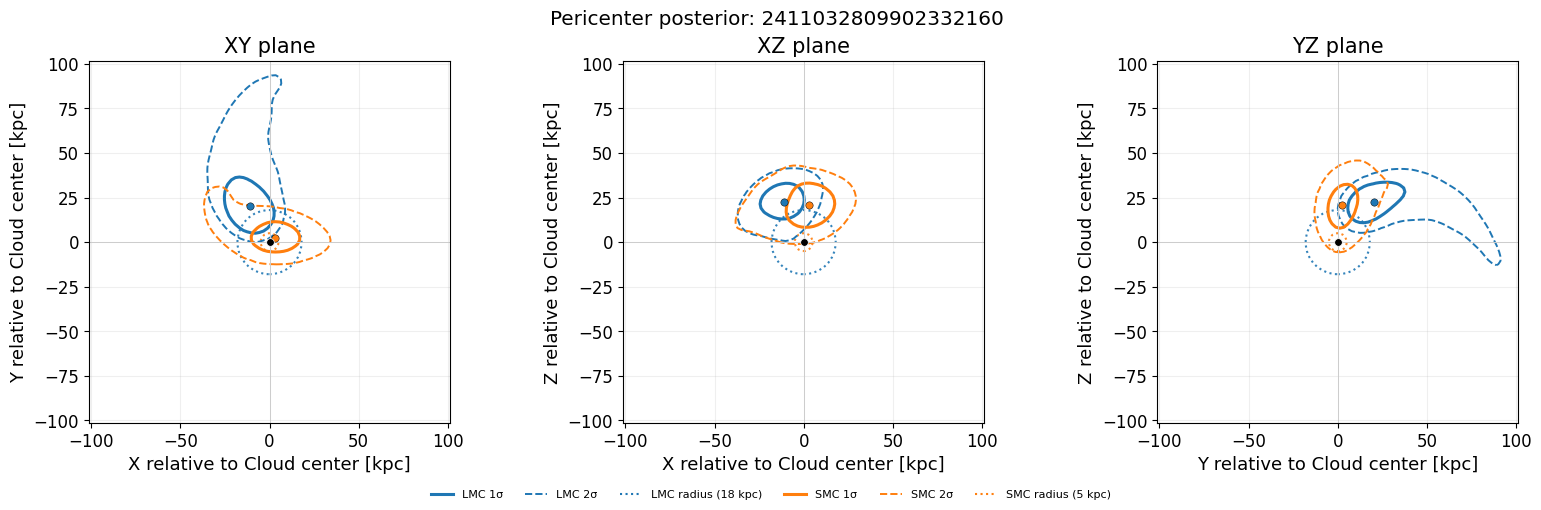

In [124]:
# Candidate 2411032809902332160: XY, XZ, and YZ pericenter planes.
star_index = 0
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
planes = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

for ax, (x_index, y_index, x_name, y_name) in zip(axes, planes):
    panel_limit = pericenter_panel_limits[star_index]
    plot_range = [[-panel_limit, panel_limit], [-panel_limit, panel_limit]]

    for cloud_name, cloud_xyz, cloud_valid, cloud_color in [
        ("LMC", lmc_pericenter_xyz, lmc_pericenter_valid, "tab:blue"),
        ("SMC", smc_pericenter_xyz, smc_pericenter_valid, "tab:orange"),
    ]:
        x_samples = cloud_xyz[star_index, cloud_valid[star_index], x_index]
        y_samples = cloud_xyz[star_index, cloud_valid[star_index], y_index]
        density, x_edges, y_edges = np.histogram2d(
            x_samples, y_samples, bins=90, range=plot_range,
        )
        density = gaussian_filter(density, sigma=2.0)
        ordered_density = np.sort(density.ravel())[::-1]
        enclosed_mass = np.cumsum(ordered_density) / ordered_density.sum()
        level_68 = ordered_density[np.searchsorted(enclosed_mass, 0.6827)]
        level_95 = ordered_density[np.searchsorted(enclosed_mass, 0.9545)]
        x_centers = 0.5 * (x_edges[1:] + x_edges[:-1])
        y_centers = 0.5 * (y_edges[1:] + y_edges[:-1])
        ax.contour(
            x_centers, y_centers, density.T,
            levels=[level_95, level_68], colors=[cloud_color],
            linestyles=["--", "-"], linewidths=[1.4, 2.2],
        )
        ax.scatter(np.median(x_samples), np.median(y_samples), s=28,
                   color=cloud_color, edgecolor="black", linewidth=0.35, zorder=5)

    ax.axhline(0, color="0.8", lw=0.7)
    ax.axvline(0, color="0.8", lw=0.7)
    ax.add_patch(plt.Circle((0, 0), lmc_scale_radius, fill=False,
                            color="tab:blue", ls=":", lw=1.5, alpha=0.9, zorder=1))
    ax.add_patch(plt.Circle((0, 0), smc_scale_radius, fill=False,
                            color="tab:orange", ls=":", lw=1.5, alpha=0.9, zorder=1))
    ax.scatter(0, 0, s=30, color="black", edgecolor="white",
               linewidth=0.5, zorder=6)
    ax.set_xlabel(f"{x_name} relative to Cloud center [kpc]")
    ax.set_ylabel(f"{y_name} relative to Cloud center [kpc]")
    ax.set_title(f"{x_name}{y_name} plane")
    ax.set_xlim(-panel_limit, panel_limit)
    ax.set_ylim(-panel_limit, panel_limit)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)

fig.legend(handles=[
    Line2D([0], [0], color="tab:blue", lw=2.2, label="LMC 1σ"),
    Line2D([0], [0], color="tab:blue", lw=1.4, ls="--", label="LMC 2σ"),
    Line2D([0], [0], color="tab:blue", lw=1.5, ls=":",
           label=f"LMC radius ({lmc_scale_radius:g} kpc)"),
    Line2D([0], [0], color="tab:orange", lw=2.2, label="SMC 1σ"),
    Line2D([0], [0], color="tab:orange", lw=1.4, ls="--", label="SMC 2σ"),
    Line2D([0], [0], color="tab:orange", lw=1.5, ls=":",
           label=f"SMC radius ({smc_scale_radius:g} kpc)"),
], loc="outside lower center", ncol=6, fontsize=8, frameon=False)
fig.suptitle(f"Pericenter posterior: {pericenter_labels[star_index].replace('GaiaDR3_', '')}")
plt.show()

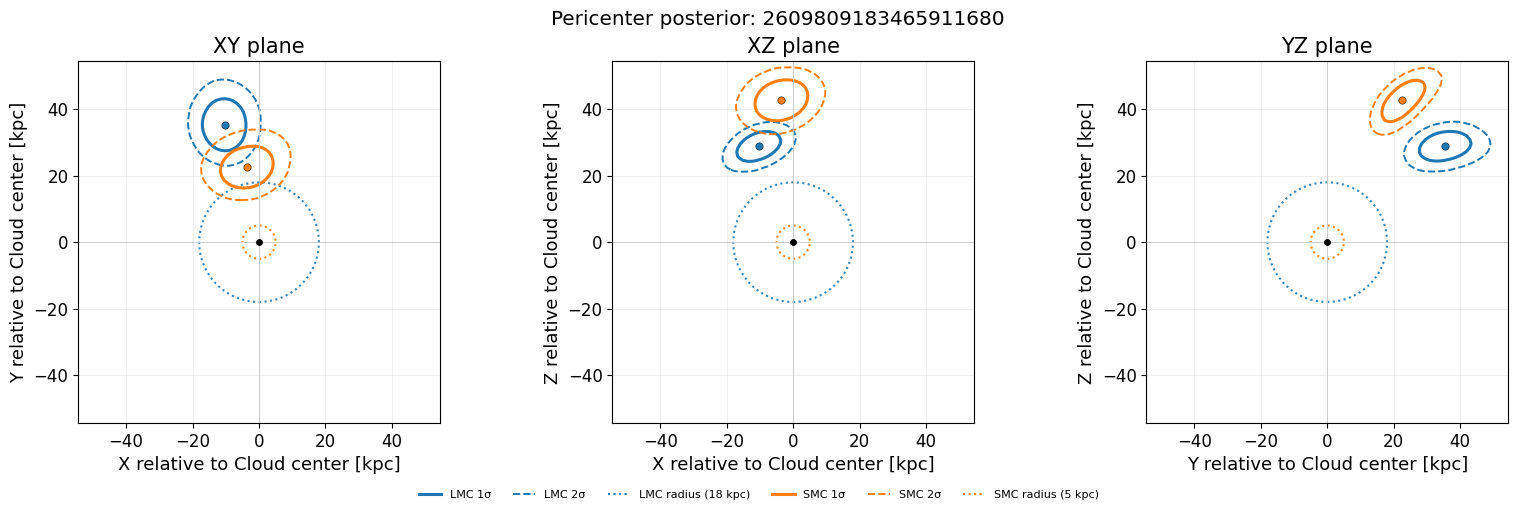

In [125]:
# One independent three-panel figure for this candidate; change the index to retarget this cell.
for star_index in [1]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    planes = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

    for ax, (x_index, y_index, x_name, y_name) in zip(axes, planes):
        panel_limit = pericenter_panel_limits[star_index]
        plot_range = [[-panel_limit, panel_limit], [-panel_limit, panel_limit]]

        for cloud_name, cloud_xyz, cloud_valid, cloud_color in [
            ("LMC", lmc_pericenter_xyz, lmc_pericenter_valid, "tab:blue"),
            ("SMC", smc_pericenter_xyz, smc_pericenter_valid, "tab:orange"),
        ]:
            x_samples = cloud_xyz[star_index, cloud_valid[star_index], x_index]
            y_samples = cloud_xyz[star_index, cloud_valid[star_index], y_index]
            density, x_edges, y_edges = np.histogram2d(
                x_samples, y_samples, bins=90, range=plot_range,
            )
            density = gaussian_filter(density, sigma=2.0)
            ordered_density = np.sort(density.ravel())[::-1]
            enclosed_mass = np.cumsum(ordered_density) / ordered_density.sum()
            level_68 = ordered_density[np.searchsorted(enclosed_mass, 0.6827)]
            level_95 = ordered_density[np.searchsorted(enclosed_mass, 0.9545)]
            x_centers = 0.5 * (x_edges[1:] + x_edges[:-1])
            y_centers = 0.5 * (y_edges[1:] + y_edges[:-1])
            ax.contour(
                x_centers, y_centers, density.T,
                levels=[level_95, level_68], colors=[cloud_color],
                linestyles=["--", "-"], linewidths=[1.4, 2.2],
            )
            ax.scatter(np.median(x_samples), np.median(y_samples), s=28,
                       color=cloud_color, edgecolor="black", linewidth=0.35, zorder=5)

        ax.axhline(0, color="0.8", lw=0.7)
        ax.axvline(0, color="0.8", lw=0.7)
        ax.add_patch(plt.Circle((0, 0), lmc_scale_radius, fill=False,
                                color="tab:blue", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.add_patch(plt.Circle((0, 0), smc_scale_radius, fill=False,
                                color="tab:orange", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.scatter(0, 0, s=30, color="black", edgecolor="white",
                   linewidth=0.5, zorder=6)
        ax.set_xlabel(f"{x_name} relative to Cloud center [kpc]")
        ax.set_ylabel(f"{y_name} relative to Cloud center [kpc]")
        ax.set_title(f"{x_name}{y_name} plane")
        ax.set_xlim(-panel_limit, panel_limit)
        ax.set_ylim(-panel_limit, panel_limit)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

    fig.legend(handles=[
        Line2D([0], [0], color="tab:blue", lw=2.2, label="LMC 1σ"),
        Line2D([0], [0], color="tab:blue", lw=1.4, ls="--", label="LMC 2σ"),
        Line2D([0], [0], color="tab:blue", lw=1.5, ls=":",
               label=f"LMC radius ({lmc_scale_radius:g} kpc)"),
        Line2D([0], [0], color="tab:orange", lw=2.2, label="SMC 1σ"),
        Line2D([0], [0], color="tab:orange", lw=1.4, ls="--", label="SMC 2σ"),
        Line2D([0], [0], color="tab:orange", lw=1.5, ls=":",
               label=f"SMC radius ({smc_scale_radius:g} kpc)"),
    ], loc="outside lower center", ncol=6, fontsize=8, frameon=False)
    fig.suptitle(f"Pericenter posterior: {pericenter_labels[star_index].replace('GaiaDR3_', '')}")
    plt.show()

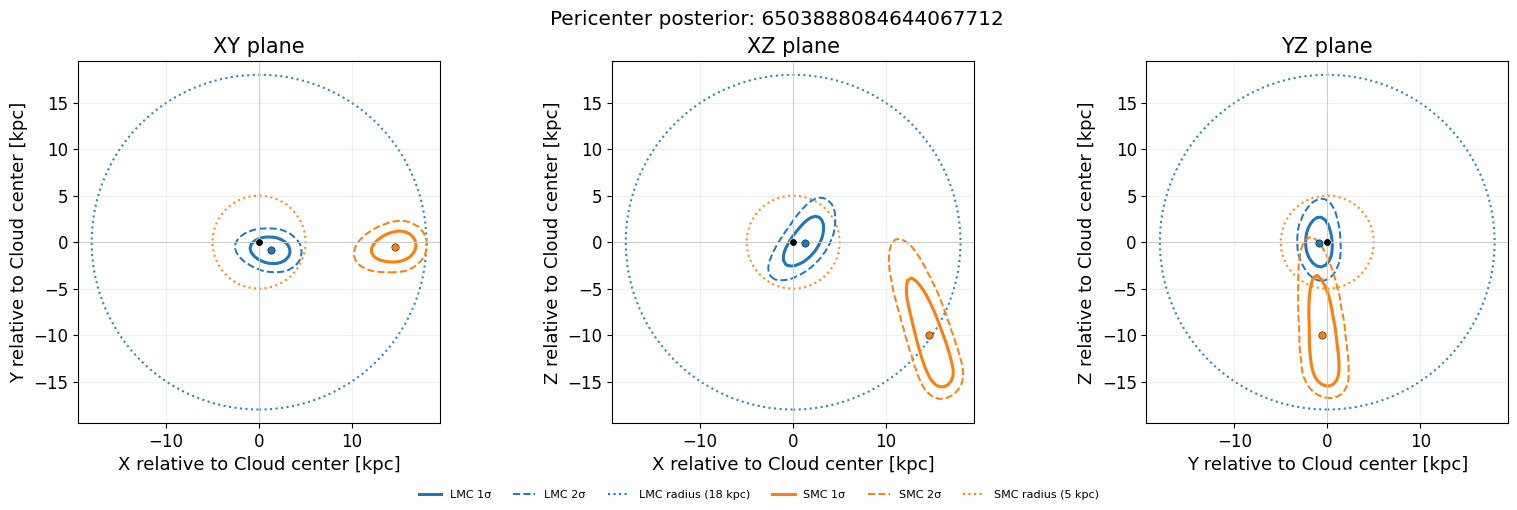

In [126]:
# One independent three-panel figure for this candidate; change the index to retarget this cell.
for star_index in [2]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    planes = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

    for ax, (x_index, y_index, x_name, y_name) in zip(axes, planes):
        panel_limit = pericenter_panel_limits[star_index]
        plot_range = [[-panel_limit, panel_limit], [-panel_limit, panel_limit]]

        for cloud_name, cloud_xyz, cloud_valid, cloud_color in [
            ("LMC", lmc_pericenter_xyz, lmc_pericenter_valid, "tab:blue"),
            ("SMC", smc_pericenter_xyz, smc_pericenter_valid, "tab:orange"),
        ]:
            x_samples = cloud_xyz[star_index, cloud_valid[star_index], x_index]
            y_samples = cloud_xyz[star_index, cloud_valid[star_index], y_index]
            density, x_edges, y_edges = np.histogram2d(
                x_samples, y_samples, bins=90, range=plot_range,
            )
            density = gaussian_filter(density, sigma=2.0)
            ordered_density = np.sort(density.ravel())[::-1]
            enclosed_mass = np.cumsum(ordered_density) / ordered_density.sum()
            level_68 = ordered_density[np.searchsorted(enclosed_mass, 0.6827)]
            level_95 = ordered_density[np.searchsorted(enclosed_mass, 0.9545)]
            x_centers = 0.5 * (x_edges[1:] + x_edges[:-1])
            y_centers = 0.5 * (y_edges[1:] + y_edges[:-1])
            ax.contour(
                x_centers, y_centers, density.T,
                levels=[level_95, level_68], colors=[cloud_color],
                linestyles=["--", "-"], linewidths=[1.4, 2.2],
            )
            ax.scatter(np.median(x_samples), np.median(y_samples), s=28,
                       color=cloud_color, edgecolor="black", linewidth=0.35, zorder=5)

        ax.axhline(0, color="0.8", lw=0.7)
        ax.axvline(0, color="0.8", lw=0.7)
        ax.add_patch(plt.Circle((0, 0), lmc_scale_radius, fill=False,
                                color="tab:blue", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.add_patch(plt.Circle((0, 0), smc_scale_radius, fill=False,
                                color="tab:orange", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.scatter(0, 0, s=30, color="black", edgecolor="white",
                   linewidth=0.5, zorder=6)
        ax.set_xlabel(f"{x_name} relative to Cloud center [kpc]")
        ax.set_ylabel(f"{y_name} relative to Cloud center [kpc]")
        ax.set_title(f"{x_name}{y_name} plane")
        ax.set_xlim(-panel_limit, panel_limit)
        ax.set_ylim(-panel_limit, panel_limit)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

    fig.legend(handles=[
        Line2D([0], [0], color="tab:blue", lw=2.2, label="LMC 1σ"),
        Line2D([0], [0], color="tab:blue", lw=1.4, ls="--", label="LMC 2σ"),
        Line2D([0], [0], color="tab:blue", lw=1.5, ls=":",
               label=f"LMC radius ({lmc_scale_radius:g} kpc)"),
        Line2D([0], [0], color="tab:orange", lw=2.2, label="SMC 1σ"),
        Line2D([0], [0], color="tab:orange", lw=1.4, ls="--", label="SMC 2σ"),
        Line2D([0], [0], color="tab:orange", lw=1.5, ls=":",
               label=f"SMC radius ({smc_scale_radius:g} kpc)"),
    ], loc="outside lower center", ncol=6, fontsize=8, frameon=False)
    fig.suptitle(f"Pericenter posterior: {pericenter_labels[star_index].replace('GaiaDR3_', '')}")
    plt.show()

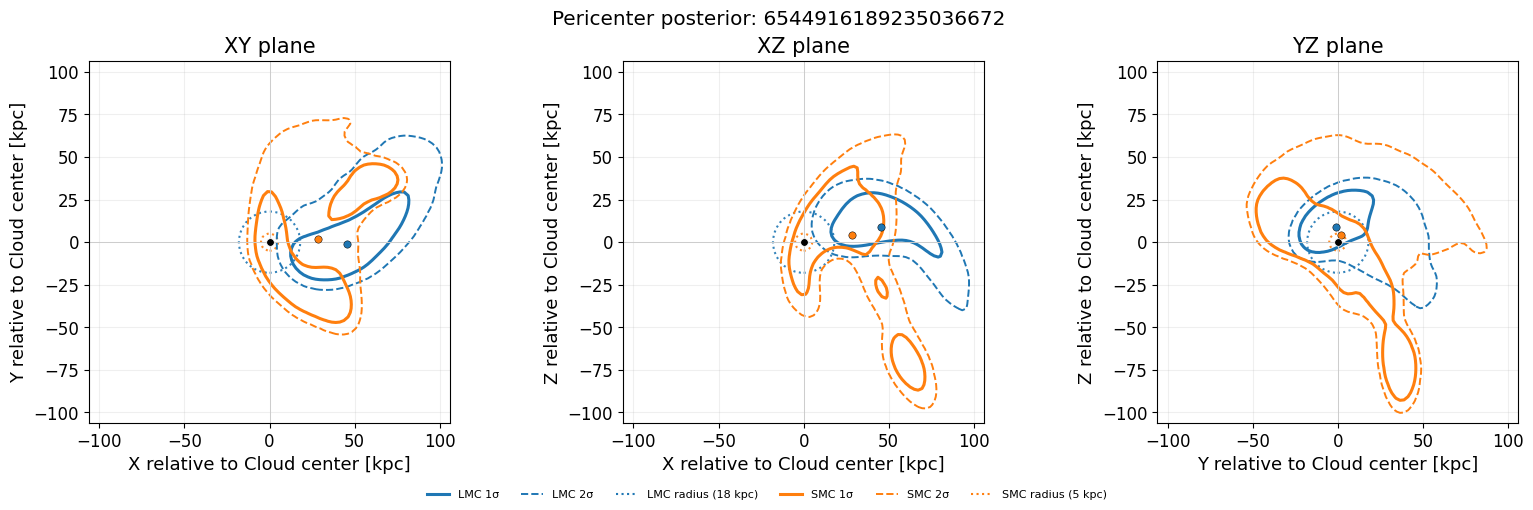

In [127]:
# One independent three-panel figure for this candidate; change the index to retarget this cell.
for star_index in [3]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    planes = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

    for ax, (x_index, y_index, x_name, y_name) in zip(axes, planes):
        panel_limit = pericenter_panel_limits[star_index]
        plot_range = [[-panel_limit, panel_limit], [-panel_limit, panel_limit]]

        for cloud_name, cloud_xyz, cloud_valid, cloud_color in [
            ("LMC", lmc_pericenter_xyz, lmc_pericenter_valid, "tab:blue"),
            ("SMC", smc_pericenter_xyz, smc_pericenter_valid, "tab:orange"),
        ]:
            x_samples = cloud_xyz[star_index, cloud_valid[star_index], x_index]
            y_samples = cloud_xyz[star_index, cloud_valid[star_index], y_index]
            density, x_edges, y_edges = np.histogram2d(
                x_samples, y_samples, bins=90, range=plot_range,
            )
            density = gaussian_filter(density, sigma=2.0)
            ordered_density = np.sort(density.ravel())[::-1]
            enclosed_mass = np.cumsum(ordered_density) / ordered_density.sum()
            level_68 = ordered_density[np.searchsorted(enclosed_mass, 0.6827)]
            level_95 = ordered_density[np.searchsorted(enclosed_mass, 0.9545)]
            x_centers = 0.5 * (x_edges[1:] + x_edges[:-1])
            y_centers = 0.5 * (y_edges[1:] + y_edges[:-1])
            ax.contour(
                x_centers, y_centers, density.T,
                levels=[level_95, level_68], colors=[cloud_color],
                linestyles=["--", "-"], linewidths=[1.4, 2.2],
            )
            ax.scatter(np.median(x_samples), np.median(y_samples), s=28,
                       color=cloud_color, edgecolor="black", linewidth=0.35, zorder=5)

        ax.axhline(0, color="0.8", lw=0.7)
        ax.axvline(0, color="0.8", lw=0.7)
        ax.add_patch(plt.Circle((0, 0), lmc_scale_radius, fill=False,
                                color="tab:blue", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.add_patch(plt.Circle((0, 0), smc_scale_radius, fill=False,
                                color="tab:orange", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.scatter(0, 0, s=30, color="black", edgecolor="white",
                   linewidth=0.5, zorder=6)
        ax.set_xlabel(f"{x_name} relative to Cloud center [kpc]")
        ax.set_ylabel(f"{y_name} relative to Cloud center [kpc]")
        ax.set_title(f"{x_name}{y_name} plane")
        ax.set_xlim(-panel_limit, panel_limit)
        ax.set_ylim(-panel_limit, panel_limit)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

    fig.legend(handles=[
        Line2D([0], [0], color="tab:blue", lw=2.2, label="LMC 1σ"),
        Line2D([0], [0], color="tab:blue", lw=1.4, ls="--", label="LMC 2σ"),
        Line2D([0], [0], color="tab:blue", lw=1.5, ls=":",
               label=f"LMC radius ({lmc_scale_radius:g} kpc)"),
        Line2D([0], [0], color="tab:orange", lw=2.2, label="SMC 1σ"),
        Line2D([0], [0], color="tab:orange", lw=1.4, ls="--", label="SMC 2σ"),
        Line2D([0], [0], color="tab:orange", lw=1.5, ls=":",
               label=f"SMC radius ({smc_scale_radius:g} kpc)"),
    ], loc="outside lower center", ncol=6, fontsize=8, frameon=False)
    fig.suptitle(f"Pericenter posterior: {pericenter_labels[star_index].replace('GaiaDR3_', '')}")
    plt.show()

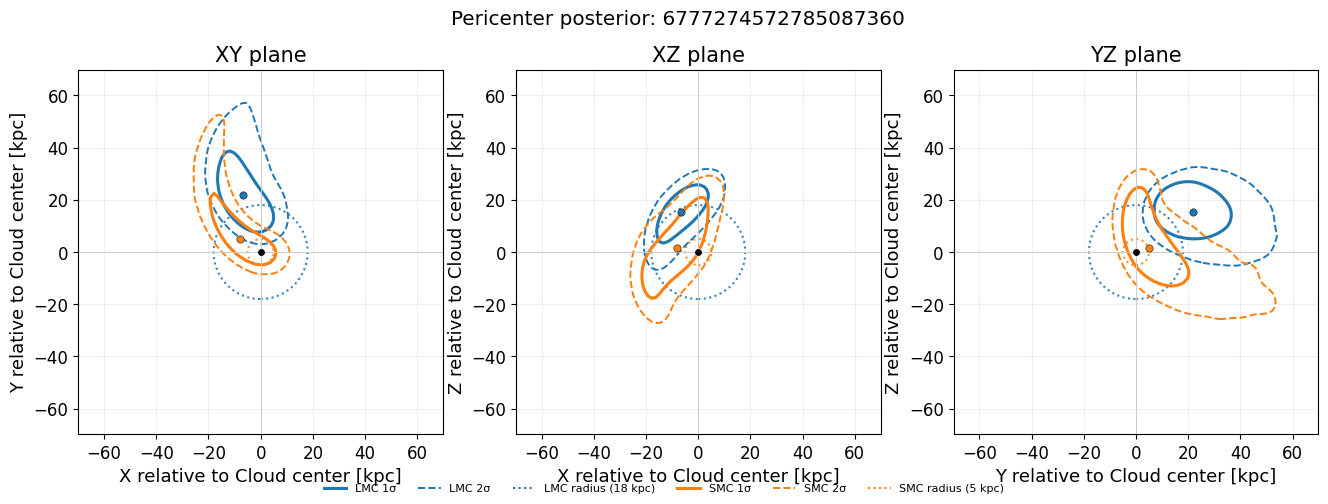

In [128]:
# One independent three-panel figure for this candidate; change the index to retarget this cell.
for star_index in [4]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=False)
    planes = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

    for ax, (x_index, y_index, x_name, y_name) in zip(axes, planes):
        panel_limit = pericenter_panel_limits[star_index]
        plot_range = [[-panel_limit, panel_limit], [-panel_limit, panel_limit]]

        for cloud_name, cloud_xyz, cloud_valid, cloud_color in [
            ("LMC", lmc_pericenter_xyz, lmc_pericenter_valid, "tab:blue"),
            ("SMC", smc_pericenter_xyz, smc_pericenter_valid, "tab:orange"),
        ]:
            x_samples = cloud_xyz[star_index, cloud_valid[star_index], x_index]
            y_samples = cloud_xyz[star_index, cloud_valid[star_index], y_index]
            density, x_edges, y_edges = np.histogram2d(
                x_samples, y_samples, bins=90, range=plot_range,
            )
            density = gaussian_filter(density, sigma=2.0)
            ordered_density = np.sort(density.ravel())[::-1]
            enclosed_mass = np.cumsum(ordered_density) / ordered_density.sum()
            level_68 = ordered_density[np.searchsorted(enclosed_mass, 0.6827)]
            level_95 = ordered_density[np.searchsorted(enclosed_mass, 0.9545)]
            x_centers = 0.5 * (x_edges[1:] + x_edges[:-1])
            y_centers = 0.5 * (y_edges[1:] + y_edges[:-1])
            ax.contour(
                x_centers, y_centers, density.T,
                levels=[level_95, level_68], colors=[cloud_color],
                linestyles=["--", "-"], linewidths=[1.4, 2.2],
            )
            ax.scatter(np.median(x_samples), np.median(y_samples), s=28,
                       color=cloud_color, edgecolor="black", linewidth=0.35, zorder=5)

        ax.axhline(0, color="0.8", lw=0.7)
        ax.axvline(0, color="0.8", lw=0.7)
        ax.add_patch(plt.Circle((0, 0), lmc_scale_radius, fill=False,
                                color="tab:blue", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.add_patch(plt.Circle((0, 0), smc_scale_radius, fill=False,
                                color="tab:orange", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.scatter(0, 0, s=30, color="black", edgecolor="white",
                   linewidth=0.5, zorder=6)
        ax.set_xlabel(f"{x_name} relative to Cloud center [kpc]")
        ax.set_ylabel(f"{y_name} relative to Cloud center [kpc]")
        ax.set_title(f"{x_name}{y_name} plane")
        ax.set_xlim(-panel_limit, panel_limit)
        ax.set_ylim(-panel_limit, panel_limit)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

    fig.legend(handles=[
        Line2D([0], [0], color="tab:blue", lw=2.2, label="LMC 1σ"),
        Line2D([0], [0], color="tab:blue", lw=1.4, ls="--", label="LMC 2σ"),
        Line2D([0], [0], color="tab:blue", lw=1.5, ls=":",
               label=f"LMC radius ({lmc_scale_radius:g} kpc)"),
        Line2D([0], [0], color="tab:orange", lw=2.2, label="SMC 1σ"),
        Line2D([0], [0], color="tab:orange", lw=1.4, ls="--", label="SMC 2σ"),
        Line2D([0], [0], color="tab:orange", lw=1.5, ls=":",
               label=f"SMC radius ({smc_scale_radius:g} kpc)"),
    ], loc="outside lower center", ncol=6, fontsize=8, frameon=False)
    fig.suptitle(f"Pericenter posterior: {pericenter_labels[star_index].replace('GaiaDR3_', '')}")
    plt.show()

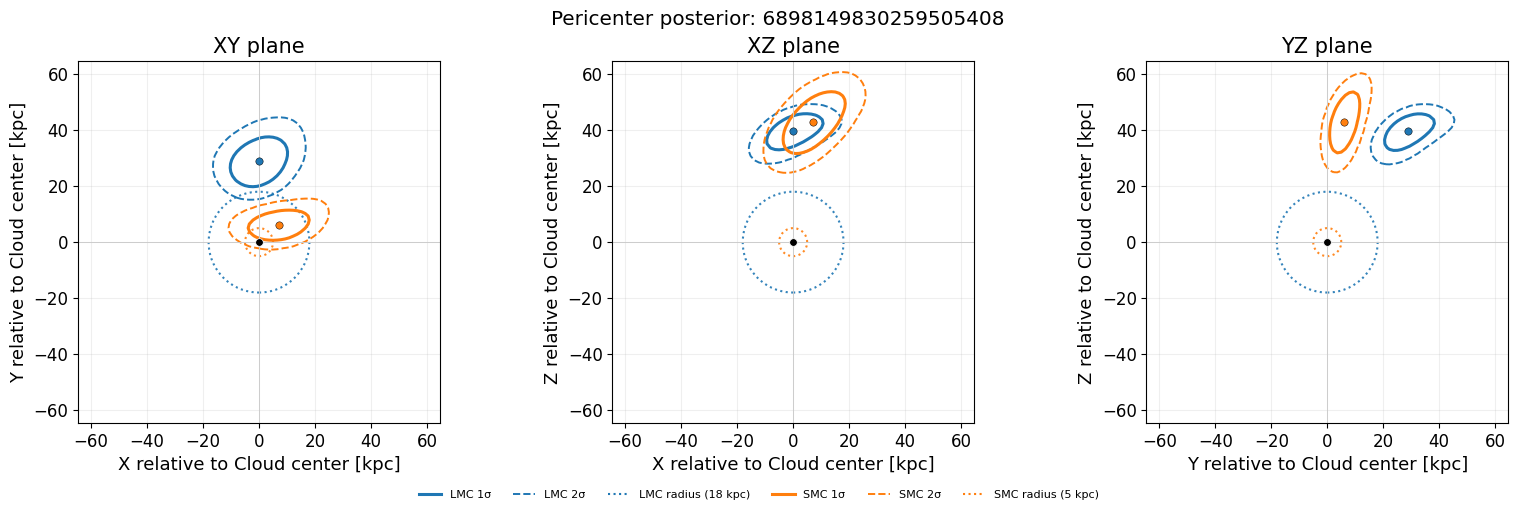

In [129]:
# One independent three-panel figure for this candidate; change the index to retarget this cell.
for star_index in [5]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    planes = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

    for ax, (x_index, y_index, x_name, y_name) in zip(axes, planes):
        panel_limit = pericenter_panel_limits[star_index]
        plot_range = [[-panel_limit, panel_limit], [-panel_limit, panel_limit]]

        for cloud_name, cloud_xyz, cloud_valid, cloud_color in [
            ("LMC", lmc_pericenter_xyz, lmc_pericenter_valid, "tab:blue"),
            ("SMC", smc_pericenter_xyz, smc_pericenter_valid, "tab:orange"),
        ]:
            x_samples = cloud_xyz[star_index, cloud_valid[star_index], x_index]
            y_samples = cloud_xyz[star_index, cloud_valid[star_index], y_index]
            density, x_edges, y_edges = np.histogram2d(
                x_samples, y_samples, bins=90, range=plot_range,
            )
            density = gaussian_filter(density, sigma=2.0)
            ordered_density = np.sort(density.ravel())[::-1]
            enclosed_mass = np.cumsum(ordered_density) / ordered_density.sum()
            level_68 = ordered_density[np.searchsorted(enclosed_mass, 0.6827)]
            level_95 = ordered_density[np.searchsorted(enclosed_mass, 0.9545)]
            x_centers = 0.5 * (x_edges[1:] + x_edges[:-1])
            y_centers = 0.5 * (y_edges[1:] + y_edges[:-1])
            ax.contour(
                x_centers, y_centers, density.T,
                levels=[level_95, level_68], colors=[cloud_color],
                linestyles=["--", "-"], linewidths=[1.4, 2.2],
            )
            ax.scatter(np.median(x_samples), np.median(y_samples), s=28,
                       color=cloud_color, edgecolor="black", linewidth=0.35, zorder=5)

        ax.axhline(0, color="0.8", lw=0.7)
        ax.axvline(0, color="0.8", lw=0.7)
        ax.add_patch(plt.Circle((0, 0), lmc_scale_radius, fill=False,
                                color="tab:blue", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.add_patch(plt.Circle((0, 0), smc_scale_radius, fill=False,
                                color="tab:orange", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.scatter(0, 0, s=30, color="black", edgecolor="white",
                   linewidth=0.5, zorder=6)
        ax.set_xlabel(f"{x_name} relative to Cloud center [kpc]")
        ax.set_ylabel(f"{y_name} relative to Cloud center [kpc]")
        ax.set_title(f"{x_name}{y_name} plane")
        ax.set_xlim(-panel_limit, panel_limit)
        ax.set_ylim(-panel_limit, panel_limit)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

    fig.legend(handles=[
        Line2D([0], [0], color="tab:blue", lw=2.2, label="LMC 1σ"),
        Line2D([0], [0], color="tab:blue", lw=1.4, ls="--", label="LMC 2σ"),
        Line2D([0], [0], color="tab:blue", lw=1.5, ls=":",
               label=f"LMC radius ({lmc_scale_radius:g} kpc)"),
        Line2D([0], [0], color="tab:orange", lw=2.2, label="SMC 1σ"),
        Line2D([0], [0], color="tab:orange", lw=1.4, ls="--", label="SMC 2σ"),
        Line2D([0], [0], color="tab:orange", lw=1.5, ls=":",
               label=f"SMC radius ({smc_scale_radius:g} kpc)"),
    ], loc="outside lower center", ncol=6, fontsize=8, frameon=False)
    fig.suptitle(f"Pericenter posterior: {pericenter_labels[star_index].replace('GaiaDR3_', '')}")
    plt.show()

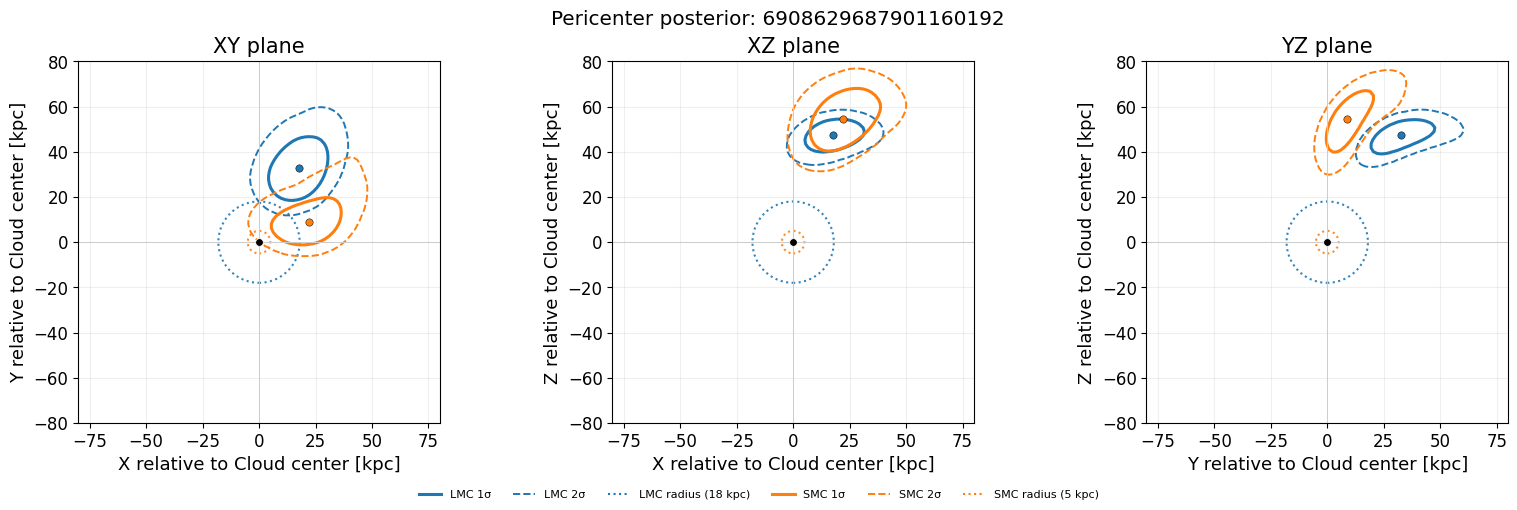

In [130]:
# One independent three-panel figure for this candidate; change the index to retarget this cell.
for star_index in [6]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    planes = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

    for ax, (x_index, y_index, x_name, y_name) in zip(axes, planes):
        panel_limit = pericenter_panel_limits[star_index]
        plot_range = [[-panel_limit, panel_limit], [-panel_limit, panel_limit]]

        for cloud_name, cloud_xyz, cloud_valid, cloud_color in [
            ("LMC", lmc_pericenter_xyz, lmc_pericenter_valid, "tab:blue"),
            ("SMC", smc_pericenter_xyz, smc_pericenter_valid, "tab:orange"),
        ]:
            x_samples = cloud_xyz[star_index, cloud_valid[star_index], x_index]
            y_samples = cloud_xyz[star_index, cloud_valid[star_index], y_index]
            density, x_edges, y_edges = np.histogram2d(
                x_samples, y_samples, bins=90, range=plot_range,
            )
            density = gaussian_filter(density, sigma=2.0)
            ordered_density = np.sort(density.ravel())[::-1]
            enclosed_mass = np.cumsum(ordered_density) / ordered_density.sum()
            level_68 = ordered_density[np.searchsorted(enclosed_mass, 0.6827)]
            level_95 = ordered_density[np.searchsorted(enclosed_mass, 0.9545)]
            x_centers = 0.5 * (x_edges[1:] + x_edges[:-1])
            y_centers = 0.5 * (y_edges[1:] + y_edges[:-1])
            ax.contour(
                x_centers, y_centers, density.T,
                levels=[level_95, level_68], colors=[cloud_color],
                linestyles=["--", "-"], linewidths=[1.4, 2.2],
            )
            ax.scatter(np.median(x_samples), np.median(y_samples), s=28,
                       color=cloud_color, edgecolor="black", linewidth=0.35, zorder=5)

        ax.axhline(0, color="0.8", lw=0.7)
        ax.axvline(0, color="0.8", lw=0.7)
        ax.add_patch(plt.Circle((0, 0), lmc_scale_radius, fill=False,
                                color="tab:blue", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.add_patch(plt.Circle((0, 0), smc_scale_radius, fill=False,
                                color="tab:orange", ls=":", lw=1.5, alpha=0.9, zorder=1))
        ax.scatter(0, 0, s=30, color="black", edgecolor="white",
                   linewidth=0.5, zorder=6)
        ax.set_xlabel(f"{x_name} relative to Cloud center [kpc]")
        ax.set_ylabel(f"{y_name} relative to Cloud center [kpc]")
        ax.set_title(f"{x_name}{y_name} plane")
        ax.set_xlim(-panel_limit, panel_limit)
        ax.set_ylim(-panel_limit, panel_limit)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

    fig.legend(handles=[
        Line2D([0], [0], color="tab:blue", lw=2.2, label="LMC 1σ"),
        Line2D([0], [0], color="tab:blue", lw=1.4, ls="--", label="LMC 2σ"),
        Line2D([0], [0], color="tab:blue", lw=1.5, ls=":",
               label=f"LMC radius ({lmc_scale_radius:g} kpc)"),
        Line2D([0], [0], color="tab:orange", lw=2.2, label="SMC 1σ"),
        Line2D([0], [0], color="tab:orange", lw=1.4, ls="--", label="SMC 2σ"),
        Line2D([0], [0], color="tab:orange", lw=1.5, ls=":",
               label=f"SMC radius ({smc_scale_radius:g} kpc)"),
    ], loc="outside lower center", ncol=6, fontsize=8, frameon=False)
    fig.suptitle(f"Pericenter posterior: {pericenter_labels[star_index].replace('GaiaDR3_', '')}")
    plt.show()

## All candidates in the pericenter XY plane

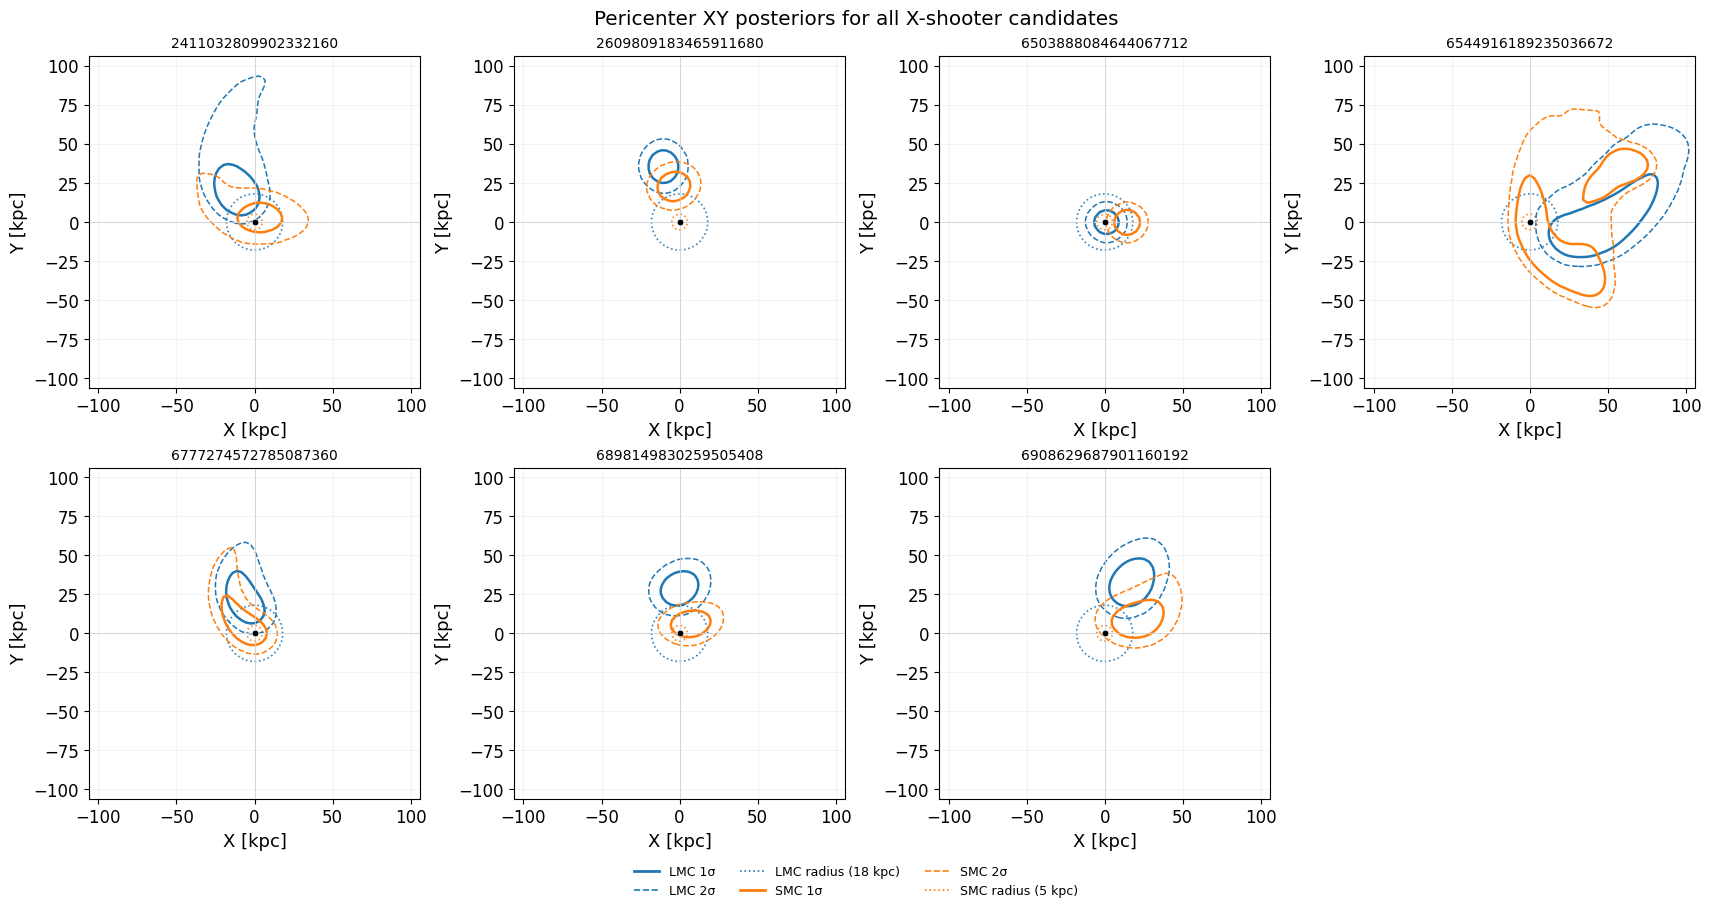

In [131]:
# One grid figure containing the LMC and SMC XY contours for all candidates.
fig, axes = plt.subplots(2, 4, figsize=(17, 9), constrained_layout=True)
axes = axes.ravel()
grid_panel_limit = np.max(pericenter_panel_limits)
grid_plot_range = [[-grid_panel_limit, grid_panel_limit],
                   [-grid_panel_limit, grid_panel_limit]]

for star_index, ax in enumerate(axes[:len(pericenter_labels)]):

    for cloud_xyz, cloud_valid, cloud_color in [
        (lmc_pericenter_xyz, lmc_pericenter_valid, "tab:blue"),
        (smc_pericenter_xyz, smc_pericenter_valid, "tab:orange"),
    ]:
        x_samples = cloud_xyz[star_index, cloud_valid[star_index], 0]
        y_samples = cloud_xyz[star_index, cloud_valid[star_index], 1]
        density, x_edges, y_edges = np.histogram2d(
            x_samples, y_samples, bins=75, range=grid_plot_range,
        )
        density = gaussian_filter(density, sigma=1.8)
        ordered_density = np.sort(density.ravel())[::-1]
        enclosed_mass = np.cumsum(ordered_density) / ordered_density.sum()
        level_68 = ordered_density[np.searchsorted(enclosed_mass, 0.6827)]
        level_95 = ordered_density[np.searchsorted(enclosed_mass, 0.9545)]
        x_centers = 0.5 * (x_edges[1:] + x_edges[:-1])
        y_centers = 0.5 * (y_edges[1:] + y_edges[:-1])
        ax.contour(x_centers, y_centers, density.T,
                   levels=[level_95, level_68], colors=[cloud_color],
                   linestyles=["--", "-"], linewidths=[1.1, 1.8])

    ax.axhline(0, color="0.82", lw=0.6)
    ax.axvline(0, color="0.82", lw=0.6)
    ax.add_patch(plt.Circle((0, 0), lmc_scale_radius, fill=False,
                            color="tab:blue", ls=":", lw=1.2, alpha=0.9, zorder=1))
    ax.add_patch(plt.Circle((0, 0), smc_scale_radius, fill=False,
                            color="tab:orange", ls=":", lw=1.2, alpha=0.9, zorder=1))
    ax.scatter(0, 0, s=22, color="black", edgecolor="white",
               linewidth=0.4, zorder=6)
    ax.set_xlabel("X [kpc]")
    ax.set_ylabel("Y [kpc]")
    ax.set_title(pericenter_labels[star_index].replace("GaiaDR3_", ""), fontsize=10)
    ax.set_xlim(-grid_panel_limit, grid_panel_limit)
    ax.set_ylim(-grid_panel_limit, grid_panel_limit)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.15)

for ax in axes[len(pericenter_labels):]:
    ax.set_visible(False)

fig.legend(handles=[
    Line2D([0], [0], color="tab:blue", lw=2, label="LMC 1σ"),
    Line2D([0], [0], color="tab:blue", lw=1.2, ls="--", label="LMC 2σ"),
    Line2D([0], [0], color="tab:blue", lw=1.2, ls=":",
           label=f"LMC radius ({lmc_scale_radius:g} kpc)"),
    Line2D([0], [0], color="tab:orange", lw=2, label="SMC 1σ"),
    Line2D([0], [0], color="tab:orange", lw=1.2, ls="--", label="SMC 2σ"),
    Line2D([0], [0], color="tab:orange", lw=1.2, ls=":",
           label=f"SMC radius ({smc_scale_radius:g} kpc)"),
], loc="outside lower center", ncol=3, frameon=False)
fig.suptitle("Pericenter XY posteriors for all X-shooter candidates")
plt.show()

## Pericenter radius and Cartesian-coordinate distributions

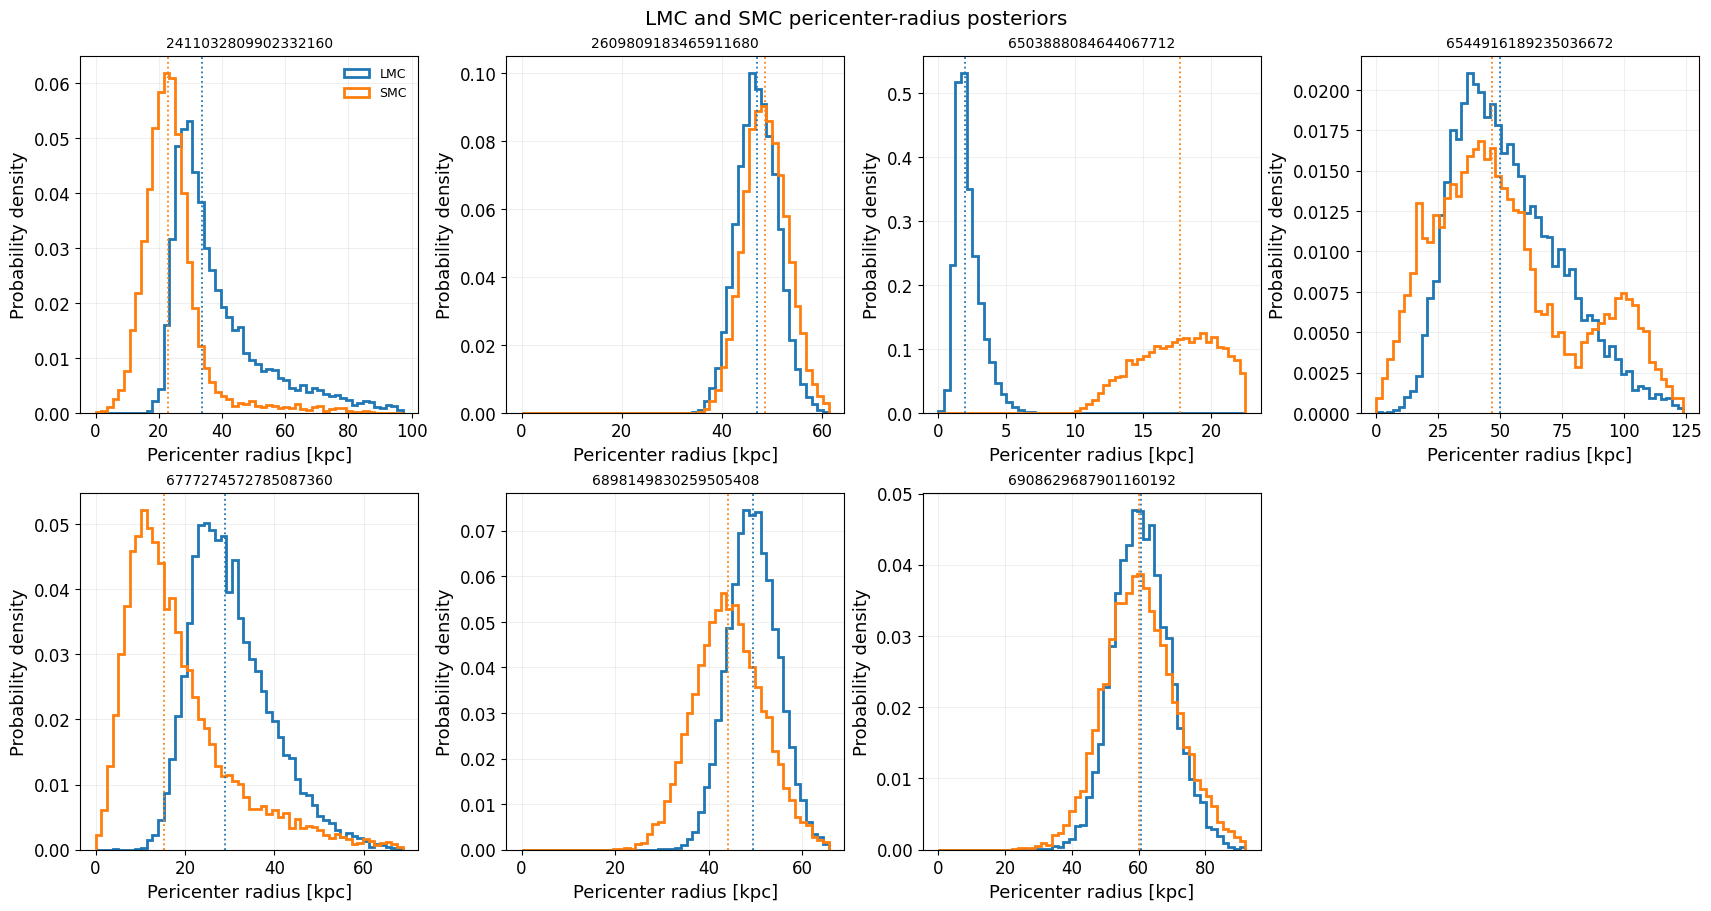

In [132]:
# Pericenter-radius distributions: one panel per star, LMC and SMC overlaid.
fig, axes = plt.subplots(2, 4, figsize=(17, 9), constrained_layout=True)
axes = axes.ravel()

for star_index, ax in enumerate(axes[:len(pericenter_labels)]):
    lmc_radius_samples = lmc_pericenter_radius[star_index, lmc_pericenter_valid[star_index]]
    smc_radius_samples = smc_pericenter_radius[star_index, smc_pericenter_valid[star_index]]
    radius_high = np.percentile(np.concatenate([lmc_radius_samples, smc_radius_samples]), 99.75)
    radius_bins = np.linspace(0, radius_high, 55)
    ax.hist(lmc_radius_samples, bins=radius_bins, density=True, histtype="step",
            lw=2, color="tab:blue", label="LMC")
    ax.hist(smc_radius_samples, bins=radius_bins, density=True, histtype="step",
            lw=2, color="tab:orange", label="SMC")
    ax.axvline(np.median(lmc_radius_samples), color="tab:blue", ls=":", lw=1.3)
    ax.axvline(np.median(smc_radius_samples), color="tab:orange", ls=":", lw=1.3)
    ax.set_xlabel("Pericenter radius [kpc]")
    ax.set_ylabel("Probability density")
    ax.set_title(pericenter_labels[star_index].replace("GaiaDR3_", ""), fontsize=10)
    ax.grid(alpha=0.2)

for ax in axes[len(pericenter_labels):]:
    ax.set_visible(False)

axes[0].legend(frameon=False)
fig.suptitle("LMC and SMC pericenter-radius posteriors")
plt.show()

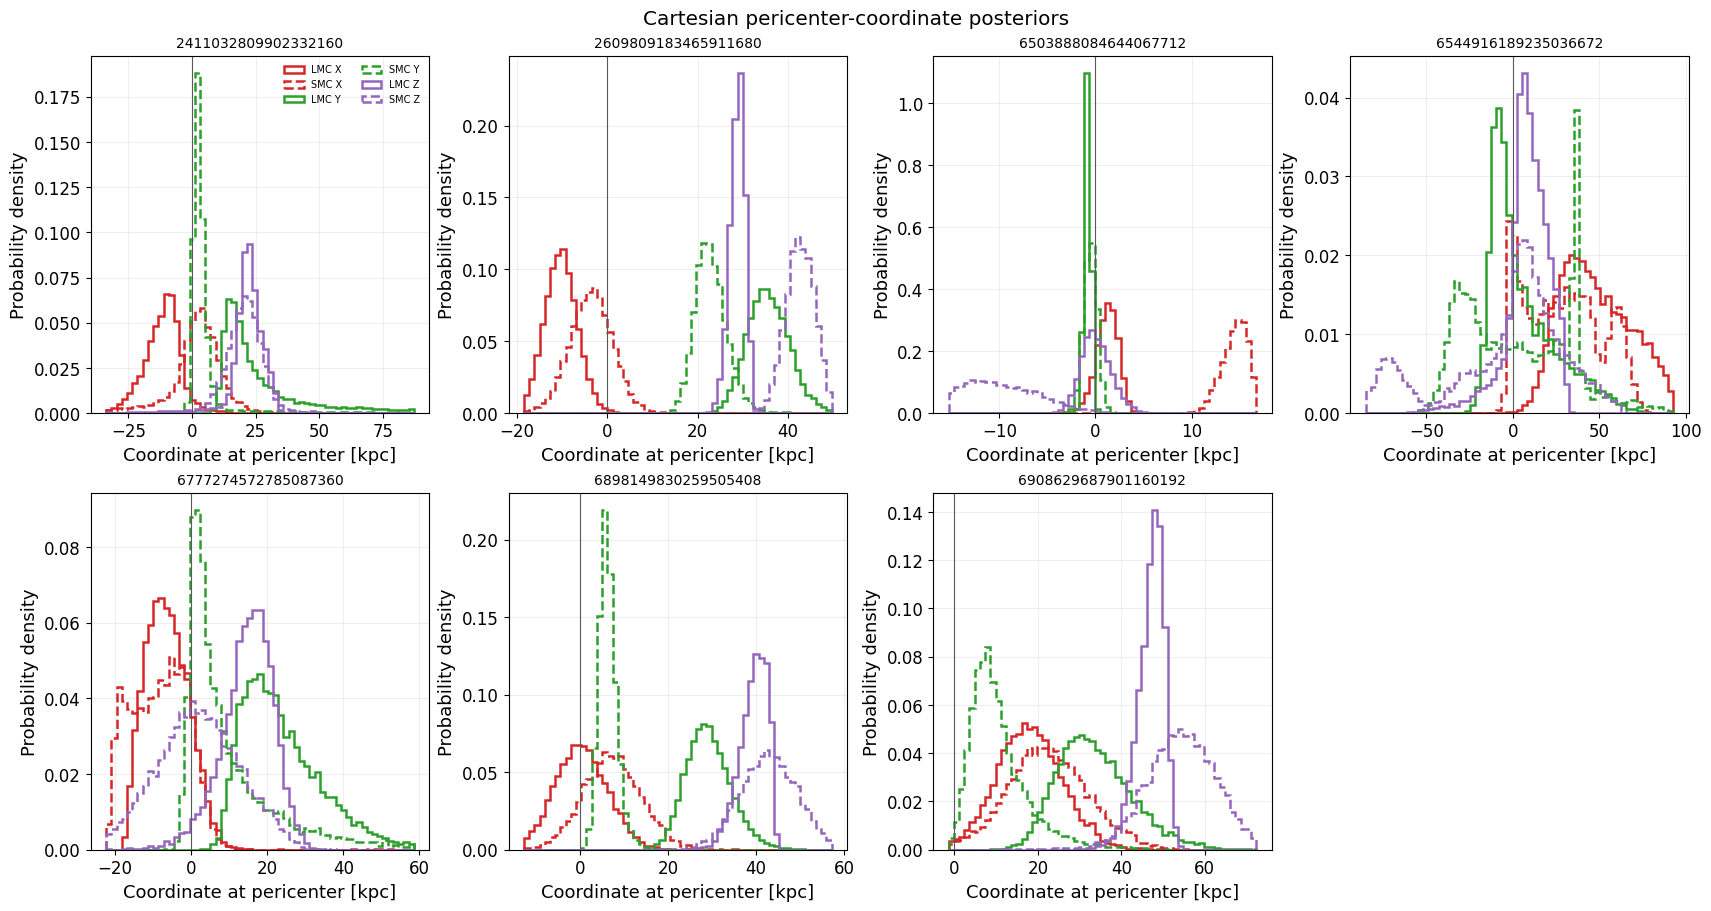

In [133]:
# Pericenter X, Y, and Z distributions in one panel per star.
# Coordinate is encoded by color; Cloud frame is encoded by line style.
fig, axes = plt.subplots(2, 4, figsize=(17, 9), constrained_layout=True)
axes = axes.ravel()
coordinate_names = ["X", "Y", "Z"]
coordinate_colors = ["tab:red", "tab:green", "tab:purple"]

for star_index, ax in enumerate(axes[:len(pericenter_labels)]):
    valid_lmc_xyz = lmc_pericenter_xyz[star_index, lmc_pericenter_valid[star_index]]
    valid_smc_xyz = smc_pericenter_xyz[star_index, smc_pericenter_valid[star_index]]
    coordinate_low, coordinate_high = np.percentile(
        np.concatenate([valid_lmc_xyz.ravel(), valid_smc_xyz.ravel()]),
        [0.25, 99.75],
    )
    coordinate_bins = np.linspace(coordinate_low, coordinate_high, 60)

    for coordinate_index, (coordinate_name, coordinate_color) in enumerate(
        zip(coordinate_names, coordinate_colors)
    ):
        ax.hist(valid_lmc_xyz[:, coordinate_index], bins=coordinate_bins,
                density=True, histtype="step", lw=1.8, color=coordinate_color,
                ls="-", label=f"LMC {coordinate_name}")
        ax.hist(valid_smc_xyz[:, coordinate_index], bins=coordinate_bins,
                density=True, histtype="step", lw=1.8, color=coordinate_color,
                ls="--", label=f"SMC {coordinate_name}")

    ax.axvline(0, color="0.35", lw=0.8)
    ax.set_xlabel("Coordinate at pericenter [kpc]")
    ax.set_ylabel("Probability density")
    ax.set_title(pericenter_labels[star_index].replace("GaiaDR3_", ""), fontsize=10)
    ax.grid(alpha=0.2)

for ax in axes[len(pericenter_labels):]:
    ax.set_visible(False)

axes[0].legend(ncol=2, fontsize=7, frameon=False)
fig.suptitle("Cartesian pericenter-coordinate posteriors")
plt.show()